# Resonance Mode Energy Transfer (RMET) Model - Resonace Modes Analysis

This notebook presents parts of the framework of a computer model implementation of the **RMET Theoretical and Mathematical model**  beginning with the analysis of eigen modes.

## Table of Contents
1. [Fundamental Field Setup](#1-Fundamental-Field-Definitions)
2. [Enhanced Resonance Mode Analysis](#2-enhanced-resonance-mode-analysis) 

# 1 Fundamental Field Definitions

## 1.0 Core Object and Fundamental Field Definitions

In [5]:

# === RMET Core OOP Definitions ===
import math
import numpy as np
from collections import defaultdict
from scipy.linalg import eigh
import warnings
warnings.filterwarnings('ignore')

class Node:
    def __init__(self, id, position, velocity=0.0):
        self.id = id
        self.position = tuple(position)
        self.velocity = velocity
        self.state = {"displacement": 0.0}

    def update_state(self, displacement, velocity):
        self.state["displacement"] = displacement
        self.velocity = velocity

    def __repr__(self):
        return f"Node({self.id}, pos={self.position})"

class BoundaryNode(Node):
    def __init__(self, id, position, velocity=0.0, boundary_type="fixed"):
        super().__init__(id, position, velocity)
        self.boundary_type = boundary_type

    def apply_boundary_condition(self):
        if self.boundary_type == "fixed":
            self.velocity = 0.0
        elif self.boundary_type == "absorbing":
            self.velocity *= 0.9

class ProjectiveBoundaryNode(BoundaryNode):
    def __init__(self, id, position, node_type="surface", boundary_type="projective"):
        super().__init__(id, position, velocity=0.0, boundary_type=boundary_type)
        self.node_type = node_type
        self.connectors_region = []
        self.connectors_virtual = []
        self.virtual_stiffness = None

    def configure_connectors(self, field, effective_virtual_stiffness=None):
        (i, j, k) = self.position
        nx, ny, nz = field.dimensions
        directions = [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]
        neighbors = []
        for dx, dy, dz in directions:
            ni, nj, nk = i + dx, j + dy, k + dz
            if 0 <= ni < nx and 0 <= nj < ny and 0 <= nk < nz:
                neighbors.append((ni, nj, nk))
        if self.node_type == "surface":
            interior_neighbors = [n for n in neighbors if not field._is_boundary_position(n)]
            planar_neighbors = [n for n in neighbors if field._is_boundary_position(n) and n != self.id]
            self.connectors_region = planar_neighbors[:4] + interior_neighbors[:1]
            self.connectors_virtual = [("outward_normal", effective_virtual_stiffness or field.default_virtual_stiffness)]
        elif self.node_type == "edge":
            self.connectors_region = neighbors[:4]
            self.connectors_virtual = [("proj_1", effective_virtual_stiffness or field.default_virtual_stiffness),
                                      ("proj_2", effective_virtual_stiffness or field.default_virtual_stiffness)]
        elif self.node_type == "corner":
            self.connectors_region = neighbors[:2]
            self.connectors_virtual = [("proj_1", effective_virtual_stiffness or field.default_virtual_stiffness),
                                      ("proj_2", effective_virtual_stiffness or field.default_virtual_stiffness)]
        else:
            self.connectors_region = neighbors
            self.connectors_virtual = [("outward", effective_virtual_stiffness or field.default_virtual_stiffness)]
        self.virtual_stiffness = effective_virtual_stiffness or field.default_virtual_stiffness

    def compute_effective_force(self, displacement_vector, field_index_map):
        idx = field_index_map[self.id]
        x_boundary = displacement_vector[idx]
        kvirt = self.virtual_stiffness if self.virtual_stiffness is not None else 1.0
        return -kvirt * x_boundary

    def __repr__(self):
        return f"ProjectiveBoundaryNode({self.id}, type={self.node_type})"

class Connector:
    def __init__(self, node_a, node_b, stiffness=1.0):
        self.node_a = node_a
        self.node_b = node_b
        self.stiffness = stiffness

    def compute_force(self):
        dx = (self.node_b.state["displacement"] - self.node_a.state["displacement"])
        return self.stiffness * dx

    def endpoints(self):
        return (self.node_a.id, self.node_b.id)

    def __repr__(self):
        return f"Connector({self.node_a.id},{self.node_b.id},k={self.stiffness})"

class ResonancePattern:
    def __init__(self, name, node_positions, mode_type='localized'):
        self.name = name
        self.node_positions = list(node_positions)
        self.mode_type = mode_type
        self.dispersion_k = np.array([])
        self.dispersion_omega = np.array([])
        self.natural_frequency = 0.0
        self.localization_factor = 0.0
        self.max_group_velocity = 0.0
        self.spatial_extent = float(len(self.node_positions))
        self.stability_threshold = 0.0

class FundamentalField:
    def __init__(self, dimensions=(20,20,20), spacing=1.0, default_stiffness=1.0, default_virtual_stiffness=0.5, damping=0.01):
        self.dimensions = tuple(dimensions)
        self.spacing = spacing
        self.default_stiffness = default_stiffness
        self.default_virtual_stiffness = default_virtual_stiffness
        self.damping = damping
        self.nodes = {}
        self.connectors = []
        self.boundary_nodes = []
        self.displacements = None
        self.velocities = None
        self.node_index_map_cache = {}
        self.energy_history = []
        self.time = 0.0
        self._create_nodes()
        self._create_connectors()
        self._create_boundary_nodes_and_configure()
        self.node_index_map_cache = self.node_index_map()
        n = len(self.nodes)
        self.displacements = np.zeros(n)
        self.velocities = np.zeros(n)

    def _is_boundary_position(self, node_id):
        i, j, k = node_id
        nx, ny, nz = self.dimensions
        return (i in (0, nx-1)) or (j in (0, ny-1)) or (k in (0, nz-1))

    def _create_nodes(self):
        nx, ny, nz = self.dimensions
        for i in range(nx):
            for j in range(ny):
                for k in range(nz):
                    node_id = (i, j, k)
                    self.nodes[node_id] = Node(node_id, position=node_id)

    def _create_connectors(self):
        nx, ny, nz = self.dimensions
        directions = [(1,0,0), (0,1,0), (0,0,1)]
        for i in range(nx):
            for j in range(ny):
                for k in range(nz):
                    node_id = (i, j, k)
                    node = self.nodes[node_id]
                    for dx, dy, dz in directions:
                        ni, nj, nk = i + dx, j + dy, k + dz
                        if 0 <= ni < nx and 0 <= nj < ny and 0 <= nk < nz:
                            neighbor_id = (ni, nj, nk)
                            neighbor = self.nodes[neighbor_id]
                            k_eff = self.default_stiffness / (self.spacing**2)
                            self.connectors.append(Connector(node, neighbor, stiffness=k_eff))

    def _classify_boundary_node(self, i, j, k):
        nx, ny, nz = self.dimensions
        extremes = sum([i in (0, nx-1), j in (0, ny-1), k in (0, nz-1)])
        if extremes == 3:
            return "corner"
        elif extremes == 2:
            return "edge"
        elif extremes == 1:
            return "surface"
        else:
            return None

    def _create_boundary_nodes_and_configure(self):
        nx, ny, nz = self.dimensions
        for i in range(nx):
            for j in range(ny):
                for k in range(nz):
                    if self._is_boundary_position((i, j, k)):
                        node_id = (i, j, k)
                        node_type = self._classify_boundary_node(i, j, k)
                        proj_node = ProjectiveBoundaryNode(node_id, position=node_id, node_type=node_type)
                        self.nodes[node_id] = proj_node
                        proj_node.configure_connectors(self)
                        self.boundary_nodes.append(proj_node)

    def node_index_map(self):
        node_ids = sorted(self.nodes.keys())
        return {nid: idx for idx, nid in enumerate(node_ids)}

    def build_stiffness_matrix(self):
        node_ids = sorted(self.nodes.keys())
        n = len(node_ids)
        id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}
        K = np.zeros((n, n))
        for conn in self.connectors:
            a_id, b_id = conn.endpoints()
            i = id_to_idx[a_id]
            j = id_to_idx[b_id]
            k_eff = conn.stiffness
            K[i, i] += k_eff
            K[j, j] += k_eff
            K[i, j] -= k_eff
            K[j, i] -= k_eff
        for bnode in self.boundary_nodes:
            idx = id_to_idx[bnode.id]
            kvirt = bnode.virtual_stiffness if bnode.virtual_stiffness is not None else self.default_virtual_stiffness
            K[idx, idx] += kvirt
        return K, id_to_idx

    def compute_local_momentum(self, displacements):
        K, idmap = self.build_stiffness_matrix()
        return K.dot(displacements)

    def eigenmodes(self, num_modes=None):
        K, idmap = self.build_stiffness_matrix()
        K = 0.5 * (K + K.T)
        evals, evecs = eigh(K)
        if num_modes is not None:
            return evals[:num_modes], evecs[:, :num_modes], idmap
        return evals, evecs, idmap

    def apply_impulse(self, node_id, amplitude):
        if node_id in self.node_index_map_cache:
            idx = self.node_index_map_cache[node_id]
            self.displacements[idx] = amplitude
        else:
            print(f"Warning: Node {node_id} not found in field.")
# V1 update_dynamics
#    def update_dynamics(self, dt):
#        K, _ = self.build_stiffness_matrix()
#        accelerations = -K.dot(self.displacements) - self.damping * self.velocities
#        self.displacements += dt * self.velocities + 0.5 * dt**2 * accelerations
#        new_accelerations = -K.dot(self.displacements) - self.damping * self.velocities
#        self.velocities += 0.5 * dt * (accelerations + new_accelerations)
#        for bnode in self.boundary_nodes:
#            idx = self.node_index_map_cache[bnode.id]
#            bnode.apply_boundary_condition()
#            if bnode.boundary_type in ["fixed", "projective"]:
#                self.velocities[idx] = 0.0
#                if bnode.boundary_type == "projective":
#                    force = bnode.compute_effective_force(self.displacements, self.node_index_map_cache)
#                    self.displacements[idx] += dt * force / self.default_stiffness
#        self.time += dt

# V2 update_dynamics
    def update_dynamics(self, dt, forcing=None):
        K, _ = self.build_stiffness_matrix()
        accelerations = -K.dot(self.displacements) - self.damping * self.velocities
        if forcing is not None:
            accelerations += forcing
        self.displacements += dt * self.velocities + 0.5 * dt**2 * accelerations
        new_accelerations = -K.dot(self.displacements) - self.damping * self.velocities
        if forcing is not None:
            new_accelerations += forcing
        self.velocities += 0.5 * dt * (accelerations + new_accelerations)
        for bnode in self.boundary_nodes:
            idx = self.node_index_map_cache[bnode.id]
            bnode.apply_boundary_condition()
            if bnode.boundary_type in ["fixed", "projective"]:
                self.velocities[idx] = 0.0
                if bnode.boundary_type == "projective":
                    force = bnode.compute_effective_force(self.displacements, self.node_index_map_cache)

    def create_standard_patterns(self):
        Nx, Ny, Nz = self.dimensions
        spacing = self.spacing
        stiff = self.default_stiffness
        center = (Nx // 2, Ny // 2, Nz // 2)
        patterns = []

        # Center-localized
        radius = max(0, min(Nx, Ny) // 8)
        center_nodes = []
        for i in range(Nx):
            for j in range(Ny):
                for k in range(Nz):
                    if (i - center[0]) ** 2 + (j - center[1]) ** 2 + (k - center[2]) ** 2 <= radius ** 2:
                        center_nodes.append((i, j, k))
        if not center_nodes:
            center_nodes = [center]
        p_center = ResonancePattern("center_localized", center_nodes, mode_type="localized")
        patterns.append(p_center)

        # Dipoles (x and y)
        dipole_x_nodes = []
        dipole_y_nodes = []
        for i in range(Nx):
            for j in range(Ny):
                for k in range(Nz):
                    if i != center[0]:  # Exclude center to create opposing lobes
                        dipole_x_nodes.append((i, j, k))
                    if j != center[1]:
                        dipole_y_nodes.append((i, j, k))
        p_dx = ResonancePattern("dipole_x", dipole_x_nodes, mode_type="dipole")
        p_dy = ResonancePattern("dipole_y", dipole_y_nodes, mode_type="dipole")
        patterns += [p_dx, p_dy]

        # Plane-like
        full_nodes = [(i, j, k) for i in range(Nx) for j in range(Ny) for k in range(Nz)]
        p_px = ResonancePattern("plane_x", full_nodes, mode_type="plane")
        p_py = ResonancePattern("plane_y", full_nodes, mode_type="plane")
        patterns += [p_px, p_py]

        k_samples = np.linspace(0, np.pi, 64)
        alpha = stiff
        a = spacing if spacing > 0 else 1.0
        omega_sample = 2.0 * np.sqrt(alpha) / a * np.abs(np.sin(k_samples / 2.0))

        for pat in patterns:
            pat.dispersion_k = k_samples.copy()
            pat.dispersion_omega = omega_sample.copy()
            pat.natural_frequency = float(np.mean(pat.dispersion_omega)) if pat.dispersion_omega.size else 0.0
            pat.max_group_velocity = float(np.max(np.abs(np.gradient(pat.dispersion_omega, k_samples)))) if pat.dispersion_omega.size else 0.0
            pat.spatial_extent = float(len(pat.node_positions))
            pat.localization_factor = 1.0 / (pat.spatial_extent + 1e-12)
            pat.stability_threshold = 0.1 * (1.0 + pat.natural_frequency)

        self.resonance_patterns = patterns
        self.pattern_amplitudes = {p.name: 0.0 for p in self.resonance_patterns}

    def get_current_pattern_amplitudes(self):
        amps = {}
        displ = self.displacements
        node_map = self.node_index_map_cache
        Nx, Ny, Nz = self.dimensions
        center = (Nx // 2, Ny // 2, Nz // 2)
        if displ is None or len(node_map) == 0:
            for p in self.resonance_patterns:
                amps[p.name] = 0.0
            self.pattern_amplitudes = amps
            return amps
        for p in self.resonance_patterns:
            s = 0.0
            count = 0
            for node_pos in p.node_positions:
                idx = node_map.get(node_pos)
                if idx is None:
                    continue
                i, j, k = node_pos
                sign = 1.0
                if p.name == "dipole_x":
                    sign = 1.0 if i < center[0] else -1.0
                elif p.name == "dipole_y":
                    sign = 1.0 if j < center[1] else -1.0
                s += sign * displ[idx]
                count += 1
            amps[p.name] = (s / count) if count > 0 else 0.0
        self.pattern_amplitudes = amps
        return amps

    def get_sustained_patterns(self, min_amp=0.05):
        amps = self.get_current_pattern_amplitudes()
        sustained = []
        for p in self.resonance_patterns:
            a = amps.get(p.name, 0.0)
            if a > min_amp:
                energy_est = a * a * max(1.0, p.spatial_extent)
                sustained.append({"pattern": p, "energy": float(energy_est)})
        sustained.sort(key=lambda x: x["energy"], reverse=True)
        return sustained

    def update_pattern_analysis(self):
        amps = self.get_current_pattern_amplitudes()
        displ = self.displacements
        if displ is None:
            total_energy = 0.0
        else:
            k_eff = self.default_stiffness
            total_energy = 0.5 * k_eff * float(np.sum(displ ** 2))
        self.energy_history.append(float(total_energy))
        return {"amplitudes": amps, "energy": total_energy}

    def get_2d_field_array(self):
        Nx, Ny, Nz = self.dimensions
        arr = np.zeros((Nx, Ny))
        node_map = self.node_index_map_cache
        displ = self.displacements
        if displ is None:
            return arr
        for (i, j, k), idx in node_map.items():
            if k == 0 and 0 <= i < Nx and 0 <= j < Ny:
                arr[i, j] = displ[idx]
        return arr

# === Improved RMET Model (with bridging) ===
import matplotlib.pyplot as plt
from scipy.linalg import eigh, expm
from scipy.sparse import diags, csr_matrix, eye as sp_eye
from scipy.sparse.linalg import spsolve, splu
from scipy.ndimage import gaussian_filter
from numpy.fft import fftn, ifftn, fftshift, fftfreq
from itertools import combinations
import time
import warnings
warnings.filterwarnings('ignore')

class ImprovedRMETModel:

 
    """
    Improved RMET implementation addressing key theoretical weaknesses:
    1. Physically motivated nonlinear source terms
    2. Realistic Berry connection via magnetic flux
    3. Better mass emergence mechanism
    4. Proper boundary conditions and convergence
    """
    
    '''Intialize class - replaced 
    def __init__(self, Nx, Ny, Nz, a=1.0, alpha=1.0, boundary='periodic', damping=0.01, coupling_strength=0.1):
        import numpy as np
        from scipy.sparse import csr_matrix
        #original assignments changed 09/14/2025 based on ChatGPT recommendation
        self.Nx, self.Ny, self.Nz = Nx, Ny, Nz
        self.N = Nx * Ny * Nz
        self.a = a
        self.alpha = alpha
        self.boundary = boundary
        self.c = np.sqrt(alpha)  # Speed of light
        self.coupling_strength = 0.1  # Nonlinear coupling parameter
        self.damping = 0.01  # Lifetime/damping parameter
        
        #self.Nx = Nx
        #self.Ny = Ny
        #self.Nz = Nz
        #self.N = Nx * Ny * Nz
        #self.boundary = boundary
        #self.alpha = alpha
        #self.a = a
        #self.damping = damping
        #self.coupling_strength = coupling_strength  # Add coupling_strength
        #self.K = self._build_stiffness_matrix()
        #self.K_sparse = csr_matrix(self.K)
        #self.eigvals, self.eigvecs = self._compute_eigenmodes()
        #self.frequencies = np.sqrt(np.abs(self.eigvals))
        #self.amplitudes = np.zeros(self.N, dtype=complex) 
               
        
        print(f"Initializing {Nx}×{Ny}×{Nz} RMET lattice with {boundary} boundaries...")
        
        # Initialize FundamentalField for low-order modeling
        self.fundamental_field = None  # Placeholder for FundamentalField instance
        
        # Build stiffness matrix
        self.K = self._build_stiffness_matrix()
        self.K_sparse = csr_matrix(self.K)  # Convert to sparse format for resolvent
        # Compute eigenmodes
        print("Computing eigenmodes...")
        self.eigvals, self.eigvecs = self._compute_eigenmodes()
        self.frequencies = np.sqrt(np.abs(self.eigvals))
        
        # Initialize state vectors
        self.amplitudes = np.zeros(self.N, dtype=complex)
        self.field = np.zeros(self.N, dtype=float)
        
        # Validation
        self._validate_initialization()
        
        print(f"✅ Initialization complete. Speed of light c = {self.c:.6f}")
        print(f"✅ Frequency range: [{self.frequencies[0]:.6f}, {self.frequencies[-1]:.6f}]")
        '''
    def __init__(self, Nx, Ny, Nz, boundary='periodic', alpha=1.0, a=1.0, damping=0.01, coupling_strength=0.1):
        """
        Initialize the ImprovedRMETModel for a 3D cubic lattice.
        
        Parameters:
        -----------
        Nx, Ny, Nz : int
            Lattice dimensions
        boundary : str
            Boundary condition ('periodic' or 'fixed', default: 'periodic')
        alpha : float
            Spring constant for lattice interactions (default: 1.0)
        a : float
            Lattice spacing (default: 1.0)
        damping : float
            Damping coefficient for mode evolution (default: 0.01)
        coupling_strength : float
            Nonlinear coupling strength for interactions (default: 0.1)
        """
        import numpy as np
        from scipy.sparse import csr_matrix
        
        self.Nx = Nx
        self.Ny = Ny
        self.Nz = Nz
        self.N = Nx * Ny * Nz
        self.shape = (Nx, Ny, Nz)  # Add shape attribute for coupling toolkit
        self.boundary = boundary
        self.alpha = alpha
        self.a = a
        self.damping = damping
        self.coupling_strength = coupling_strength
        self.c = np.sqrt(alpha)  # Speed of light, derived from spring constant
        
        # Initialize core attributes
        try:
            self.K = self._build_stiffness_matrix()
            self.K_sparse = csr_matrix(self.K)
            self.eigvals, self.eigvecs = self._compute_eigenmodes()
            self.frequencies = np.sqrt(np.abs(self.eigvals))
            self.amplitudes = np.zeros(self.N, dtype=complex)
        except AttributeError as e:
            raise AttributeError(f"Initialization failed: Ensure _build_stiffness_matrix and _compute_eigenmodes are defined. Error: {str(e)}")

    @property
    def field(self):
        """
        Compute the displacement field from mode amplitudes and eigenvectors.
        
        Returns:
        --------
        numpy.ndarray
            Displacement field as a 1D array of shape (N,)
        """
        import numpy as np
        return np.sum(self.amplitudes[:, np.newaxis] * self.eigvecs, axis=0)  

    def integrate_fundamental_field(self, low_order_field: FundamentalField):
        """
        Upscale low-order stiffness and eigenmodes from a FundamentalField instance into the aggregate model.
        :param low_order_field: FundamentalField instance with node-based lattice data
        """
        # Ensure compatible dimensions (or handle resizing)
        if low_order_field.dimensions != (self.Nx, self.Ny, self.Nz):
            print(f"Warning: Dimension mismatch. Resizing low-order field {low_order_field.dimensions} to match {self.Nx, self.Ny, self.Nz}")
            # Simple upscaling: replicate low-order stiffness matrix
            scale_x = self.Nx // low_order_field.dimensions[0]
            scale_y = self.Ny // low_order_field.dimensions[1]
            scale_z = self.Nz // low_order_field.dimensions[2]
            scale = scale_x * scale_y * scale_z
        else:
            scale = 1

        # Store the FundamentalField instance
        self.fundamental_field = low_order_field
        
        # Extract low-order stiffness matrix and node map
        K_local, idmap_local = low_order_field.build_stiffness_matrix()
        
        # Map low-order node IDs to global indices (assuming compatible lattice)
        idmap_global = {nid: i for i, nid in enumerate(sorted([(i,j,k) for i in range(self.Nx) for j in range(self.Ny) for k in range(self.Nz)]))}
        
        # Upscale: Add low-order stiffness contributions to global K
        K_aggregated = np.zeros_like(self.K)
        for (i,j,k), local_idx in idmap_local.items():
            global_idx = idmap_global.get((i,j,k))
            if global_idx is not None:
                # Scale and map local stiffness to global (simple additive merge)
                K_aggregated[global_idx, global_idx] += K_local[local_idx, local_idx] * scale
                # Off-diagonal terms for connectors
                for conn in low_order_field.connectors:
                    a_id, b_id = conn.endpoints()
                    if a_id == (i,j,k):
                        global_b_idx = idmap_global.get(b_id)
                        if global_b_idx is not None:
                            K_aggregated[global_idx, global_b_idx] += K_local[local_idx, idmap_local[b_id]] * scale
                            K_aggregated[global_b_idx, global_idx] += K_local[idmap_local[b_id], local_idx] * scale
        
        # Update global stiffness matrix
        self.K += K_aggregated
        self.K_sparse = csr_matrix(self.K)
        
        # Recompute eigenmodes
        self.eigvals, self.eigvecs = self._compute_eigenmodes()
        print(f"Integrated low-order field; updated stiffness matrix and eigenmodes.")

    def _build_stiffness_matrix(self):
        """
        Build the stiffness matrix for the 3D cubic lattice.
        
        Returns:
        --------
        numpy.ndarray
            Stiffness matrix K of shape (N, N)
        """
        import numpy as np
        N = self.N
        K = np.zeros((N, N))
        for idx in range(N):
            x, y, z = self._get_coordinates(idx)
            K[idx, idx] = 6 * self.alpha / self.a**2  # Diagonal: 6 nearest neighbors
            for dx, dy, dz in [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]:
                x_n, y_n, z_n = x + dx, y + dy, z + dz
                if self.boundary == 'periodic':
                    x_n, y_n, z_n = x_n % self.Nx, y_n % self.Ny, z_n % self.Nz
                elif self.boundary == 'fixed' and (x_n < 0 or x_n >= self.Nx or 
                                                y_n < 0 or y_n >= self.Ny or 
                                                z_n < 0 or z_n >= self.Nz):
                    continue
                if 0 <= x_n < self.Nx and 0 <= y_n < self.Ny and 0 <= z_n < self.Nz:
                    idx_n = x_n + y_n * self.Nx + z_n * self.Nx * self.Ny
                    K[idx, idx_n] = -self.alpha / self.a**2
        return K
    
    def _build_absorbing_stiffness(self):
        # Placeholder; implement as per original notebook
        K = np.zeros((self.N, self.N))
        K += self.alpha * np.eye(self.N)
        return K
    
    def _build_free_stiffness(self):
        # Placeholder; implement as per original notebook
        K = np.zeros((self.N, self.N))
        K += self.alpha * np.eye(self.N)
        return K
    
    def _get_index(self, i, j, k):
        """Map 3D indices to 1D index"""
        return i * self.Ny * self.Nz + j * self.Nz + k
    
    def _compute_eigenmodes(self):
        """
        Compute eigenmodes of the stiffness matrix.
        
        Returns:
        --------
        tuple
            (eigenvalues, eigenvectors) where eigenvectors have shape (N, N)
        """
        import numpy as np
        from scipy.linalg import eigh
        try:
            eigvals, eigvecs = eigh(self.K, check_finite=False)
            # Ensure eigenvectors are normalized
            eigvecs /= np.sqrt(np.sum(np.abs(eigvecs)**2, axis=0) + 1e-12)
            return eigvals, eigvecs
        except Exception as e:
            raise RuntimeError(f"Eigenmode computation failed: {str(e)}")
    
    def _validate_initialization(self):
        """Validate model setup"""
        assert self.K.shape == (self.N, self.N), "Stiffness matrix size mismatch"
        assert np.allclose(self.K, self.K.T), "Stiffness matrix not symmetric"
        print("Validation passed: Stiffness matrix is symmetric and correctly sized.")

    def _get_coordinates(self, idx):
        """
        Convert flat index to 3D lattice coordinates (x, y, z).
        
        Parameters:
        -----------
        idx : int
            Flat index in the lattice
        
        Returns:
        --------
        tuple
            (x, y, z) coordinates
        """
        import numpy as np
        z = idx // (self.Nx * self.Ny)
        y = (idx % (self.Nx * self.Ny)) // self.Nx
        x = idx % self.Nx
        return (x, y, z)


    def eigenmodes(self, num_modes=None):
            """
            Public method to mimic FundamentalField.eigenmodes() for compatibility.
            Returns eigenvalues, eigenvectors, and a node index map.
            """
            # Generate a simple node index map compatible with FundamentalField's format
            idmap = {
                (i // (self.Ny * self.Nz), (i // self.Nz) % self.Ny, i % self.Nz): i
                for i in range(self.N)
            }
            if num_modes is not None:
                return self.eigvals[:num_modes], self.eigvecs[:, :num_modes], idmap
            return self.eigvals, self.eigvecs, idmap
    
    def set_initial_amplitudes(self, mode_indices, values):
        """
        Set initial modal amplitudes for specified modes.
        
        Parameters:
        mode_indices: list of int - Mode indices to set
        values: list of float or complex - Amplitude values
        """
        if len(mode_indices) != len(values):
            raise ValueError("Mode indices and values must have the same length")
        for idx, val in zip(mode_indices, values):
            if idx >= self.N or idx < 0:
                raise IndexError(f"Mode index {idx} out of range (0 to {self.N-1})")
            self.amplitudes[idx] = complex(val)
            
    def propagate(self, dt, damping=0.01):
        """
        Propagate modal amplitudes forward in time by dt using the stiffness matrix and damping.
        
        Parameters:
        -----------
        dt : float
            Time step for propagation
        damping : float
            Damping coefficient for the system (default matches class damping)
        
        Notes:
        ------
        Evolves self.amplitudes using a simple numerical scheme based on the eigenmode dynamics.
        Assumes amplitudes are in the modal basis defined by self.eigvecs and self.frequencies.
        """
        # Ensure amplitudes are initialized
        if self.amplitudes is None:
            self.amplitudes = np.zeros(self.N, dtype=complex)
        
        # Current amplitudes
        a = self.amplitudes.copy()
        
        # Compute accelerations from stiffness matrix: a_n'' = -ω_n^2 a_n - γ a_n'
        # Since amplitudes are in modal basis, use frequencies directly
        accelerations = -self.frequencies**2 * a - damping * a
        
        # Simple Euler step for amplitudes (first-order for simplicity, could upgrade to Verlet)
        # a(t + dt) = a(t) + dt * a'(t)
        # a'(t + dt) = a'(t) + dt * a''(t)
        velocities = -damping * a  # Approximate velocity as -γ a (modal basis)
        self.amplitudes += dt * velocities + 0.5 * dt**2 * accelerations
        
        # Update velocities for next step
        new_accelerations = -self.frequencies**2 * self.amplitudes - damping * velocities
        velocities += 0.5 * dt * (accelerations + new_accelerations)
        
        # Apply damping explicitly to amplitudes
        self.amplitudes *= np.exp(-damping * dt / 2.0)

    def run_convergence_test(self, mode_indices, property_name, size_range=None):
        """
        Run convergence test for specified modes and property by varying lattice size.
        
        Parameters:
        -----------
        mode_indices : list of int
            Indices of modes to test for convergence
        property_name : str
            Property to test ('frequencies' or 'dispersion')
        size_range : list of int, optional
            List of lattice sizes to test (e.g., [4, 6, 8]); defaults to [4, 6, 8]
        
        Returns:
        --------
        dict
            Results dictionary with lattice sizes and corresponding property values
        """
        import numpy as np
        
        if property_name not in ['frequencies', 'dispersion']:
            raise ValueError("Property must be 'frequencies' or 'dispersion'")
        
        if not mode_indices or max(mode_indices) >= self.N:
            raise ValueError("Invalid mode indices provided")
        
        # Default size range if not provided
        if size_range is None:
            size_range = [4, 6, 8]
        
        # Ensure size_range is valid
        size_range = [max(2, int(s)) for s in size_range if int(s) >= 2]
        if not size_range:
            raise ValueError("Size range must contain valid lattice sizes (>= 2)")
        
        results = {'sizes': [], 'values': {idx: [] for idx in mode_indices}}
        
        # Save original parameters
        orig_Nx, orig_Ny, orig_Nz = self.Nx, self.Ny, self.Nz
        orig_amplitudes = self.amplitudes.copy() if self.amplitudes is not None else None
        
        for size in size_range:
            # Update lattice size
            self.Nx = self.Ny = self.Nz = size
            self.N = size * size * size
            self.amplitudes = np.zeros(self.N, dtype=complex)
            
            # Rebuild stiffness matrix and recompute eigenmodes
            self.K = self._build_stiffness_matrix()
            self.K_sparse = csr_matrix(self.K)
            self.eigvals, self.eigvecs = self._compute_eigenmodes()
            self.frequencies = np.sqrt(np.abs(self.eigvals))
            
            # Store property values
            results['sizes'].append(size)
            for idx in mode_indices:
                if idx >= len(self.frequencies):
                    results['values'][idx].append(np.nan)
                    continue
                
                if property_name == 'frequencies':
                    results['values'][idx].append(self.frequencies[idx])
                else:  # dispersion
                    # Estimate k-vector via FFT
                    mode = self.eigvecs[:, idx].reshape(self.Nx, self.Ny, self.Nz)
                    mode_fft = np.fft.fftn(mode)
                    max_indices = np.unravel_index(np.argmax(np.abs(mode_fft)), mode_fft.shape)
                    kx_est = 2 * np.pi * max_indices[0] / (self.Nx * self.a)
                    ky_est = 2 * np.pi * max_indices[1] / (self.Ny * self.a)
                    kz_est = 2 * np.pi * max_indices[2] / (self.Nz * self.a)
                    k_max = np.pi / self.a
                    if kx_est > k_max: kx_est -= 2 * np.pi / self.a
                    if ky_est > k_max: ky_est -= 2 * np.pi / self.a
                    if kz_est > k_max: kz_est -= 2 * np.pi / self.a
                    
                    # Compute analytical dispersion
                    L_hat = (2 / self.a**2) * (3 - np.cos(kx_est * self.a) - 
                                            np.cos(ky_est * self.a) - np.cos(kz_est * self.a))
                    freq_analytical = np.sqrt(self.alpha * L_hat)
                    results['values'][idx].append(freq_analytical)
        
        # Restore original parameters
        self.Nx, self.Ny, self.Nz = orig_Nx, orig_Ny, orig_Nz
        self.N = orig_Nx * orig_Ny * orig_Nz
        self.amplitudes = orig_amplitudes
        self.K = self._build_stiffness_matrix()
        self.K_sparse = csr_matrix(self.K)
        self.eigvals, self.eigvecs = self._compute_eigenmodes()
        self.frequencies = np.sqrt(np.abs(self.eigvals))
        
        return results

    def visualize_mode_structure(self, mode_indices, plot_type='3d'):
        """
        Visualize the mode structure for specified modes.
        
        Parameters:
        -----------
        mode_indices : int or list of int
            Index or indices of modes to visualize
        plot_type : str
            Type of plot ('3d' for 3D visualization, 'xy' for 2D XY projection)
        
        Notes:
        ------
        Creates a 3D plot of mode amplitude or a 2D XY projection of mode amplitude.
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from mpl_toolkits.mplot3d import Axes3D
        
        if plot_type not in ['3d', 'xy']:
            raise ValueError("plot_type must be '3d' or 'xy'")
        
        # Convert single mode index to list for consistent processing
        if isinstance(mode_indices, int):
            mode_indices = [mode_indices]
        
        for mode_idx in mode_indices:
            if mode_idx >= len(self.frequencies) or mode_idx < 0:
                print(f"Mode {mode_idx}: Invalid index, skipping")
                continue
            
            # Reshape mode to 3D grid
            mode = self.eigvecs[:, mode_idx].reshape(self.Nx, self.Ny, self.Nz)
            amplitude = np.abs(mode)
            
            if plot_type == '3d':
                # Create 3D grid for plotting
                x, y, z = np.indices((self.Nx, self.Ny, self.Nz))
                
                # Create figure
                fig = plt.figure(figsize=(8, 6))
                ax = fig.add_subplot(111, projection='3d')
                
                # Scatter plot of amplitude
                scatter = ax.scatter(x, y, z, c=amplitude, cmap='viridis', s=50)
                plt.colorbar(scatter, ax=ax, label='Mode Amplitude')
                
                ax.set_xlabel('X')
                ax.set_ylabel('Y')
                ax.set_zlabel('Z')
                ax.set_title(f'Mode {mode_idx} Structure (ω={self.frequencies[mode_idx]:.4f})')
            
            else:  # plot_type == 'xy'
                # Take maximum amplitude along z-axis for 2D projection
                xy_amplitude = np.max(amplitude, axis=2)
                
                # Create figure
                fig = plt.figure(figsize=(8, 6))
                ax = fig.add_subplot(111)
                
                # 2D heatmap
                im = ax.imshow(xy_amplitude, cmap='viridis', origin='lower')
                plt.colorbar(im, ax=ax, label='Mode Amplitude')
                
                ax.set_xlabel('X')
                ax.set_ylabel('Y')
                ax.set_title(f'Mode {mode_idx} XY Projection (ω={self.frequencies[mode_idx]:.4f})')
            
            plt.show()
            
    def analyze_convergence_trends(self, convergence_results):
        """
        Analyze convergence trends for a given property across lattice sizes.
        
        Parameters:
        -----------
        convergence_results : dict
            Dictionary from run_convergence_test with keys:
            - 'sizes': list of lattice sizes tested
            - 'values': dict mapping mode indices to lists of property values
        
        Returns:
        --------
        dict
            Analysis results with convergence metrics and summary statistics
        """
        import numpy as np
        import matplotlib.pyplot as plt
        
        if 'sizes' not in convergence_results or 'values' not in convergence_results:
            raise ValueError("convergence_results must contain 'sizes' and 'values' keys")
        
        sizes = convergence_results['sizes']
        values = convergence_results['values']
        
        if not sizes or not values:
            raise ValueError("Empty sizes or values in convergence_results")
        
        analysis = {
            'mode_convergence': {},
            'average_relative_error': {},
            'convergence_rate': {}
        }
        
        print(f"\nConvergence Analysis for {len(sizes)} lattice sizes: {sizes}")
        print(f"Analyzing {len(values)} modes: {list(values.keys())}")
        
        # Analyze convergence for each mode
        for mode_idx, freqs in values.items():
            # Skip if frequencies are all NaN
            if all(np.isnan(f) for f in freqs):
                print(f"Mode {mode_idx}: Insufficient data (all NaN)")
                analysis['mode_convergence'][mode_idx] = {'status': 'failed', 'errors': []}
                continue
            
            # Compute relative errors between consecutive lattice sizes
            rel_errors = []
            valid_freqs = [f for f in freqs if not np.isnan(f)]
            if len(valid_freqs) < 2:
                print(f"Mode {mode_idx}: Insufficient valid data for convergence")
                analysis['mode_convergence'][mode_idx] = {'status': 'failed', 'errors': []}
                continue
            
            for i in range(1, len(valid_freqs)):
                if valid_freqs[i-1] > 1e-10:  # Avoid division by zero
                    rel_error = abs(valid_freqs[i] - valid_freqs[i-1]) / valid_freqs[i-1]
                    rel_errors.append(rel_error)
            
            # Summary statistics
            avg_error = np.mean(rel_errors) if rel_errors else np.nan
            status = 'converged' if (rel_errors and max(rel_errors) < 1e-2) else 'not converged'
            
            print(f"Mode {mode_idx}:")
            print(f"  Frequencies: {[f'{f:.6f}' for f in valid_freqs]}")
            print(f"  Relative errors: {[f'{e:.6f}' for e in rel_errors]}")
            print(f"  Average relative error: {avg_error:.6f}")
            print(f"  Status: {status}")
            
            analysis['mode_convergence'][mode_idx] = {
                'status': status,
                'errors': rel_errors,
                'frequencies': valid_freqs
            }
            analysis['average_relative_error'][mode_idx] = avg_error
            
            # Estimate convergence rate (assuming power-law convergence)
            if len(rel_errors) >= 2:
                # Simple estimate: log(error) vs log(size)
                log_sizes = np.log(sizes[:len(rel_errors)])
                log_errors = np.log([e for e in rel_errors if e > 1e-10])
                if len(log_errors) >= 2:
                    coeffs = np.polyfit(log_sizes[:len(log_errors)], log_errors, 1)
                    analysis['convergence_rate'][mode_idx] = -coeffs[0]  # Negative slope is convergence rate
                else:
                    analysis['convergence_rate'][mode_idx] = np.nan
            else:
                analysis['convergence_rate'][mode_idx] = np.nan
        
        # Visualize convergence trends
        plt.figure(figsize=(10, 6))
        for mode_idx, freqs in values.items():
            valid_freqs = [f if not np.isnan(f) else 0 for f in freqs]
            plt.plot(sizes, valid_freqs, marker='o', label=f'Mode {mode_idx}')
        plt.xlabel('Lattice Size (Nx = Ny = Nz)')
        plt.ylabel('Frequency')
        plt.title('Frequency Convergence Trends')
        plt.legend()
        plt.grid(True)
        plt.show()
        
        # Summary statistics
        valid_modes = [m for m, data in analysis['mode_convergence'].items() if data['status'] == 'converged']
        print("\nConvergence Summary:")
        print(f"  Total modes analyzed: {len(values)}")
        print(f"  Converged modes: {len(valid_modes)} ({100 * len(valid_modes) / len(values):.1f}%)")
        print(f"  Average convergence rate: {np.nanmean([rate for rate in analysis['convergence_rate'].values()]):.3f}")
        
        return analysis
    
    def standard_model_mode_classification(self):
        """
        Classify modes based on frequency, effective mass, and localization properties.
        
        Returns:
        --------
        dict
            Dictionary mapping mode indices to classification data including type,
            frequency, effective mass, and localization measure.
        """
        import numpy as np
        
        classification = {}
        
        for mode_idx in range(min(10, self.N)):  # Limit to first 10 modes for efficiency
            if mode_idx >= len(self.frequencies):
                continue
            
            freq = self.frequencies[mode_idx]
            mode = self.eigvecs[:, mode_idx]
            
            # Compute effective mass (simplified, using frequency-based approach)
            if freq < 1e-10:
                effective_mass = np.inf  # Zero modes treated as infinite mass
                mode_type = 'zero_mode'
            else:
                effective_mass = 1.0 / (freq**2 + 1e-12)  # Inverse square frequency approximation
                # Classify based on frequency and mass
                if freq < 0.5:
                    mode_type = 'photon_like'  # Low frequency, massless-like
                elif effective_mass < 1.0:
                    mode_type = 'lepton_like'  # Light massive particles
                else:
                    mode_type = 'hadron_like'  # Heavy massive particles
            
            # Compute localization (inverse participation ratio)
            psi_squared = np.abs(mode)**2
            localization = np.sum(psi_squared**2) / (np.sum(psi_squared)**2 + 1e-12)
            
            classification[mode_idx] = {
                'type': mode_type,
                'frequency': freq,
                'effective_mass': effective_mass,
                'localization': localization
            }
        
        return classification
    
    def compute_holonomy_improved(self, mode_indices, flux_quantum=0.05):
        """
        Compute the holonomy matrix for specified mode pairs under a synthetic magnetic flux.
        
        Parameters:
        -----------
        mode_indices : list of int
            Indices of modes to compute holonomy
        flux_quantum : float
            Strength of the synthetic magnetic flux (default: 0.05)
        
        Returns:
        --------
        numpy.ndarray
            Holonomy matrix for the specified modes
        """
        import numpy as np
        
        n_modes = len(mode_indices)
        if n_modes < 2:
            raise ValueError("At least two modes required for holonomy")
        
        # Compute Berry connection matrix
        A = np.zeros((n_modes, n_modes), dtype=complex)
        for i, idx_i in enumerate(mode_indices):
            for j, idx_j in enumerate(mode_indices):
                if i == j:
                    continue
                psi_i = self.eigvecs[:, idx_i]
                psi_j = self.eigvecs[:, idx_j]
                grad_psi_i = np.zeros((self.N, 3), dtype=complex)
                coords = np.array([self._get_coordinates(idx) for idx in range(self.N)])
                for d in range(3):
                    shifted = np.roll(psi_i, 1, axis=0)
                    grad_psi_i[:, d] = (shifted - psi_i) / self.a
                A[i, j] = np.sum(np.conj(psi_j) * np.sum(grad_psi_i * coords, axis=1)) * flux_quantum
        
        # Holonomy matrix via path-ordered exponential (simplified)
        holonomy = np.eye(n_modes, dtype=complex) + A
        return holonomy

    def compute_emergent_mass_improved(self, mode_indices, method='effective'):
        """
        Compute emergent effective mass for specified modes.
        
        Parameters:
        -----------
        mode_indices : list of int
            Indices of modes to compute mass
        method : str
            Method for mass computation ('effective' or others)
        
        Returns:
        --------
        float
            Effective mass for the mode or average mass for multiple modes
        """
        import numpy as np
        
        if method != 'effective':
            raise ValueError("Only 'effective' method is supported")
        
        masses = []
        for idx in mode_indices:
            freq = self.frequencies[idx]
            if freq < 1e-10:
                masses.append(np.inf)  # Zero modes have infinite mass
            else:
                masses.append(1.0 / (freq**2 + 1e-12))  # Inverse square frequency
        return np.mean(masses) if masses else np.inf
    
    def improved_greens_function(self, energy, mode_indices):
        """
        Compute the improved Green's function for specified modes at given energy.
        
        Parameters:
        -----------
        energy : float
            Energy at which to evaluate the Green's function
        mode_indices : list of int
            Indices of modes to include
        
        Returns:
        --------
        numpy.ndarray
            Green's function matrix for the specified modes
        """
        import numpy as np
        
        n_modes = len(mode_indices)
        G = np.zeros((n_modes, n_modes), dtype=complex)
        for i, idx_i in enumerate(mode_indices):
            omega_i = self.frequencies[idx_i]
            G[i, i] = 1.0 / (energy**2 - omega_i**2 + 1j * self.damping * energy)
        return G
    
    def _identify_goldstone_modes(self, mode_indices, coupling_strength=0.1):
        """
        Identify Goldstone modes resulting from spontaneous symmetry breaking.
        
        Parameters:
        -----------
        mode_indices : list of int
            Indices of modes involved in the symmetry breaking potential
        coupling_strength : float
            Coupling strength for the Mexican hat potential (default: 0.1)
        
        Returns:
        --------
        list
            List of mode indices identified as Goldstone modes
        """
        import numpy as np
        
        if not mode_indices:
            return []
        
        # Compute Mexican hat potential parameters
        mu2 = 1.0  # Same as in implement_mexican_hat_potential
        lmb = coupling_strength
        phi2 = np.sum(np.abs(self.amplitudes[mode_indices])**2)
        v = mu2 / lmb  # Vacuum expectation value squared
        
        # Check if symmetry is broken (v > 0 indicates SSB)
        symmetry_broken = v > 0
        
        if not symmetry_broken:
            return []
        
        # Goldstone modes are those with near-zero effective mass after SSB
        goldstone_modes = []
        for idx in mode_indices:
            # Approximate effective mass after SSB
            effective_mass = lmb * phi2  # From potential derivative
            if abs(effective_mass) < 1e-3:  # Threshold for massless modes
                goldstone_modes.append(idx)
            elif self.frequencies[idx] < 1e-2:  # Also consider near-zero frequency modes
                goldstone_modes.append(idx)
        
        # Exclude the first mode if multiple modes are provided (as in implement_mexican_hat_potential)
        if len(mode_indices) > 1:
            return goldstone_modes[1:] if goldstone_modes else []
        
        return goldstone_modes

    def implement_mexican_hat_potential(self, mode_indices, coupling_strength=0.1):
        """
        Implement Mexican hat potential for specified modes to model spontaneous symmetry breaking.
        
        Parameters:
        -----------
        mode_indices : list of int
            Indices of modes to include in the potential
        coupling_strength : float
            Coupling strength for the quartic term (default: 0.1)
        
        Returns:
        --------
        dict
            Dictionary with symmetry breaking status, total potential, and Goldstone modes
        """
        import numpy as np
        
        mu2 = 1.0
        lmb = coupling_strength
        a = self.amplitudes[mode_indices]
        phi2 = np.sum(np.abs(a)**2)
        V = -mu2 / 2 * phi2 + lmb / 4 * phi2**2
        v = mu2 / lmb
        symmetry_broken = v > 0
        goldstone_modes = self._identify_goldstone_modes(mode_indices, coupling_strength) if symmetry_broken else []
        
        return {
            'symmetry_broken': symmetry_broken,
            'total_potential': V,
            'goldstone_modes': goldstone_modes
        }   


        
        return classification         

    # ... (add remaining methods from the original ImprovedRMETModel, e.g., time evolution, nonlinear sources, etc.)

# Example usage (test the bridge):
# field = FundamentalField(dimensions=(3,3,3))
# model = ImprovedRMETModel(Nx=5, Ny=5, Nz=5, a=1.0, alpha=1.0)
# model.integrate_fundamental_field(field)
# print("Bridging successful!")

## 1.3 Eigenmode Excitation Energy Calculator

In [10]:
class RMETExcitationCalculator:
    def __init__(self, field_model):
        self.field_model = field_model
        self.eigvals, self.eigvecs, self.idmap = field_model.eigenmodes()
        self.frequencies = np.sqrt(np.abs(self.eigvals))
        self.N = len(self.eigvals)
        self.damping = getattr(field_model, 'damping', 0.01)
        self.Nx, self.Ny, self.Nz = field_model.dimensions if hasattr(field_model, 'dimensions') else (5,5,5)

    def calculate_mode_excitation_energy(self, mode_index, amplitude=1.0, efficiency_threshold=0.01):
        if mode_index >= self.N or mode_index < 0:
            raise ValueError(f"Mode index must be between 0 and {self.N-1}")
        
        eigenvector = self.eigvecs[:, mode_index]
        frequency = self.frequencies[mode_index]
        
        # Calculate required excitation pattern
        excitation_pattern = eigenvector * amplitude / np.max(np.abs(eigenvector) + 1e-12)
        
        # Energy calculation: 0.5 * k * x^2 for each node, summed
        k = getattr(self.field_model, 'default_stiffness', 1.0)
        total_energy = 0.5 * k * np.sum(excitation_pattern**2)
        
        # Analyze excitation pattern complexity
        abs_pattern = np.abs(excitation_pattern)
        significant_nodes = np.where(abs_pattern > efficiency_threshold * np.max(abs_pattern))[0]
        num_significant = len(significant_nodes)
        
        # Classify mode type based on pattern
        if num_significant <= 1:
            mode_type = 'highly localized'
            strategy_type = 'single_node'
        elif num_significant <= 5:
            mode_type = 'localized'
            strategy_type = 'few_nodes'
        elif num_significant < self.N * 0.2:
            mode_type = 'extended'
            strategy_type = 'multi_node'
        else:
            mode_type = 'global'
            strategy_type = 'distributed'
        
        # Efficiency: how concentrated the energy is
        efficiency = np.sum(abs_pattern[significant_nodes]**2) / (np.sum(abs_pattern**2) + 1e-12)
        
        # Localization measure (inverse participation ratio)
        ipr = np.sum(abs_pattern**4) / (np.sum(abs_pattern**2)**2 + 1e-12)
        
        return {
            'mode_index': mode_index,
            'frequency': float(frequency),
            'total_energy': float(total_energy),
            'excitation_pattern': {
                'full_pattern': excitation_pattern.tolist(),
                'significant_nodes': significant_nodes.tolist(),
                'significant_amplitudes': excitation_pattern[significant_nodes].tolist(),
                'num_significant_nodes': num_significant,
                'efficiency': float(efficiency),
                'excitation_strategy': {
                    'type': strategy_type,
                    'complexity': num_significant / self.N
                }
            },
            'mode_type': mode_type,
            'localization': float(ipr)
        }

    def calculate_mode_damping_and_sustain_time(self, mode_index, amplitude=1.0):
        if mode_index >= self.N or mode_index < 0:
            raise ValueError(f"Mode index must be between 0 and {self.N-1}")
        
        frequency = self.frequencies[mode_index]
        eigenvector = self.eigvecs[:, mode_index]
        
        # Calculate effective damping for the mode
        # Base damping from field
        gamma_base = self.damping
        
        # Radiation damping estimate (proportional to frequency^2 for extended modes)
        ipr = np.sum(np.abs(eigenvector)**4) / (np.sum(np.abs(eigenvector)**2)**2 + 1e-12)
        localization_factor = ipr  # Higher for localized modes
        gamma_rad = 0.01 * frequency**2 * (1 - localization_factor)  # Less radiation for localized
        
        # Surface loss for boundary-affected modes
        boundary_nodes = [idx for idx in range(self.N) if self._is_boundary_node(idx)]
        boundary_amplitude = np.sum(np.abs(eigenvector[boundary_nodes])**2)
        boundary_fraction = boundary_amplitude / (np.sum(np.abs(eigenvector)**2) + 1e-12)
        gamma_surf = 0.02 * boundary_fraction
        
        # Total damping rate
        gamma_total = gamma_base + gamma_rad + gamma_surf
        
        # Sustain time: time for amplitude to decay to 1/e
        sustain_time = 1.0 / gamma_total if gamma_total > 0 else np.inf
        
        # Half-life for energy (energy decays as exp(-2 gamma t))
        half_life = np.log(2) / (2 * gamma_total) if gamma_total > 0 else np.inf
        
        # Quality factor Q = omega / (2 gamma)
        Q = frequency / (2 * gamma_total) if gamma_total > 0 else np.inf
        
        # Classify damping regime
        if gamma_total < 0.01 * frequency:
            damping_class = 'underdamped'
        elif gamma_total < frequency:
            damping_class = 'damped'
        elif gamma_total < 2 * frequency:
            damping_class = 'critically damped'
        else:
            damping_class = 'overdamped'
        
        # Dominant loss mechanism
        losses = {
            'bulk': gamma_base,
            'radiation': gamma_rad,
            'surface': gamma_surf
        }
        dominant_loss = max(losses, key=losses.get)
        
        # Oscillations before significant decay
        oscillations_to_decay = frequency / (2 * np.pi * gamma_total) if gamma_total > 0 else np.inf
        
        return {
            'mode_index': mode_index,
            'frequency': float(frequency),
            'total_damping': float(gamma_total),
            'sustain_time': float(sustain_time),
            'half_life': float(half_life),
            'quality_factor': float(Q),
            'damping_classification': damping_class,
            'dominant_loss_mechanism': dominant_loss,
            'loss_contributions': {k: float(v) for k,v in losses.items()},
            'oscillations_to_decay': float(oscillations_to_decay)
        }

    def _is_boundary_node(self, idx):
        x, y, z = self.field_model._get_coordinates(idx) if hasattr(self.field_model, '_get_coordinates') else (idx%self.Nx, (idx//self.Nx)%self.Ny, idx//(self.Nx*self.Ny))
        return (x in (0, self.Nx-1)) or (y in (0, self.Ny-1)) or (z in (0, self.Nz-1))

    def simulate_mode_decay(self, mode_index, initial_amplitude=1.0, time_steps=1000, dt=None):
        damping_info = self.calculate_mode_damping_and_sustain_time(mode_index, initial_amplitude)
        frequency = damping_info['frequency']
        gamma = damping_info['total_damping']
        
        # Automatic dt if not provided
        if dt is None:
            period = 2 * np.pi / frequency if frequency > 0 else 1.0
            dt = period / 20 if period > 0 else 0.01
        
        times = np.arange(time_steps) * dt
        t = times
        
        if gamma == 0:
            amplitude_evol = initial_amplitude * np.cos(frequency * t)
            regime = 'undamped oscillation'
        elif gamma < frequency:
            omega_d = np.sqrt(frequency**2 - gamma**2)
            amplitude_evol = initial_amplitude * np.exp(-gamma * t) * np.cos(omega_d * t)
            regime = 'underdamped'
        elif gamma == frequency:
            amplitude_evol = initial_amplitude * (1 - gamma * t) * np.exp(-gamma * t)
            regime = 'critically damped'
        else:
            alpha1 = -gamma + np.sqrt(gamma**2 - frequency**2)
            alpha2 = -gamma - np.sqrt(gamma**2 - frequency**2)
            A = initial_amplitude / (alpha1 - alpha2)
            amplitude_evol = A * (np.exp(alpha1 * t) - np.exp(alpha2 * t))
            regime = 'overdamped'
        
        energy_evol = amplitude_evol**2  # Proportional to energy
        
        return {
            'times': times.tolist(),
            'amplitude_evolution': amplitude_evol.tolist(),
            'energy_evolution': energy_evol.tolist(),
            'regime': regime,
            'damping_info': damping_info
        }

    def calculate_sustain_times_spectrum(self, max_modes=20):
        spectrum = []
        n_modes = min(max_modes, self.N)
        
        for i in range(n_modes):
            damping_info = self.calculate_mode_damping_and_sustain_time(i)
            spectrum.append({
                'mode_index': i,
                'frequency': damping_info['frequency'],
                'sustain_time': damping_info['sustain_time'],
                'quality_factor': damping_info['quality_factor'],
                'total_damping': damping_info['total_damping'],
                'dominant_loss_mechanism': damping_info['dominant_loss_mechanism']
            })
        
        # Sort by sustain time descending
        spectrum.sort(key=lambda x: x['sustain_time'], reverse=True)
        return spectrum

    def find_longest_lived_modes(self, max_modes=10, min_sustain_time=0.0):
        spectrum = self.calculate_sustain_times_spectrum(max_modes * 2)
        long_lived = [m for m in spectrum if m['sustain_time'] >= min_sustain_time]
        long_lived.sort(key=lambda x: x['sustain_time'], reverse=True)
        return long_lived[:max_modes]

    def plot_sustain_time_analysis(self, max_modes=20):
        sustain_spectrum = self.calculate_sustain_times_spectrum(max_modes)
        
        mode_indices = [s['mode_index'] for s in sustain_spectrum]
        frequencies = [s['frequency'] for s in sustain_spectrum]
        sustain_times = [s['sustain_time'] for s in sustain_spectrum]
        quality_factors = [s['quality_factor'] for s in sustain_spectrum]
        total_damping = [s['total_damping'] for s in sustain_spectrum]
        
        sustain_times_plot = [min(t, 1000) if np.isfinite(t) else 1000 for t in sustain_times]
        quality_factors_plot = [min(q, 1000) if np.isfinite(q) else 1000 for q in quality_factors]
        
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        ax1.semilogy(mode_indices, sustain_times_plot, 'bo-', markersize=6)
        ax1.set_xlabel('Mode Index')
        ax1.set_ylabel('Sustain Time')
        ax1.set_title('Mode Sustain Times')
        ax1.grid(True, alpha=0.3)
        
        ax2.loglog(frequencies, quality_factors_plot, 'ro-', markersize=6)
        ax2.set_xlabel('Frequency ω')
        ax2.set_ylabel('Quality Factor Q')
        ax2.set_title('Quality Factor vs Frequency')
        ax2.grid(True, alpha=0.3)
        
        ax3.hist(total_damping, bins=min(10, max_modes//2), alpha=0.7, edgecolor='black')
        ax3.set_xlabel('Total Damping Rate γ')
        ax3.set_ylabel('Number of Modes')
        ax3.set_title('Damping Rate Distribution')
        ax3.grid(True, alpha=0.3)
        
        scatter = ax4.scatter(frequencies, sustain_times_plot, c=quality_factors_plot, 
                              cmap='viridis', s=60, alpha=0.7)
        ax4.set_xlabel('Frequency ω')
        ax4.set_ylabel('Sustain Time')
        ax4.set_yscale('log')
        ax4.set_title('Sustain Time vs Frequency\n(colored by Quality Factor)')
        plt.colorbar(scatter, ax=ax4, label='Quality Factor Q')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return sustain_spectrum

    def generate_excitation_instructions(self, mode_index, amplitude=1.0, efficiency_threshold=0.01):
        excitation_info = self.calculate_mode_excitation_energy(
            mode_index, amplitude, efficiency_threshold)
        
        pattern = excitation_info['excitation_pattern']
        strategy = pattern['excitation_strategy']
        
        instructions = {
            'mode_index': mode_index,
            'target_amplitude': amplitude,
            'total_energy_required': excitation_info['total_energy'],
            'instructions': []
        }
        
        instructions['instructions'].append({
            'step': 1,
            'action': 'Initialize field',
            'description': 'Set all field displacements to zero (quiescent state)',
            'implementation': 'field.displacements = np.zeros(N)'
        })
        
        if strategy['type'] == 'single_node':
            node_idx = pattern['significant_nodes'][0]
            coords = self.field_model._get_coordinates(node_idx) if hasattr(self.field_model, '_get_coordinates') else (node_idx,)
            amplitude_val = pattern['significant_amplitudes'][0]
            
            instructions['instructions'].extend([
                {
                    'step': 2,
                    'action': 'Apply single impulse',
                    'description': f'Apply impulse at node {coords} with amplitude {amplitude_val:.6f}',
                    'implementation': f'field.apply_impulse({coords}, {amplitude_val:.6f})'
                },
                {
                    'step': 3,
                    'action': 'Verify excitation',
                    'description': 'Check that the mode is excited with correct amplitude',
                    'implementation': 'Check modal projection: <ψ_n | field_state>'
                }
            ])
            
        elif strategy['type'] == 'few_nodes':
            instructions['instructions'].append({
                'step': 2,
                'action': 'Apply multi-node excitation',
                'description': f'Simultaneously excite {len(pattern["significant_nodes"])} nodes',
                'implementation': 'Apply coordinated impulses with specific amplitudes and phases'
            })
            
            for i, (node_idx, amp) in enumerate(zip(pattern['significant_nodes'], 
                                                   pattern['significant_amplitudes'])):
                coords = self.field_model._get_coordinates(node_idx) if hasattr(self.field_model, '_get_coordinates') else (node_idx,)
                instructions['instructions'].append({
                    'step': f'2.{i+1}',
                    'action': f'Excite node {i+1}',
                    'description': f'Apply amplitude {amp:.6f} at position {coords}',
                    'implementation': f'field.apply_impulse({coords}, {amp:.6f})'
                })
        
        else:
            instructions['instructions'].extend([
                {
                    'step': 2,
                    'action': 'Prepare complex excitation array',
                    'description': f'Set up {len(pattern["significant_nodes"])} coordinated excitations',
                    'implementation': 'Use phase-controlled excitation array'
                },
                {
                    'step': 3,
                    'action': 'Apply pattern',
                    'description': 'Execute spatially distributed excitation pattern',
                    'implementation': 'Apply all excitations with precise timing and amplitudes'
                }
            ])
        
        instructions['instructions'].extend([
            {
                'step': 'final-1',
                'action': 'Measure mode amplitude',
                'description': 'Verify the excited mode has the target amplitude',
                'implementation': 'modal_amplitude = np.abs(np.dot(eigenvector.conj(), field_state))'
            },
            {
                'step': 'final-2', 
                'action': 'Check energy conservation',
                'description': 'Verify total field energy matches expectation',
                'implementation': 'total_energy = 0.5 * np.sum(field_state**2 * stiffness_factors)'
            }
        ])
        
        return instructions

    def _calculate_mode_coupling(self, mode_i, mode_j):
        # Simple overlap integral for coupling strength
        vec_i = self.eigvecs[:, mode_i]
        vec_j = self.eigvecs[:, mode_j]
        
        # Nonlinear coupling proxy: |<i|j>|^2 * (some factor)
        overlap = np.abs(np.dot(vec_i.conj(), vec_j))**2
        freq_diff = np.abs(self.frequencies[mode_i] - self.frequencies[mode_j])
        
        coupling = overlap * np.exp(-freq_diff / np.mean(self.frequencies))
        return coupling * getattr(self.field_model, 'coupling_strength', 0.1)

    def find_resonant_mode_groups(self, max_modes=20, max_group_size=4):
        n_modes = min(max_modes, self.N)
        resonant_groups = []
        
        for group_size in range(2, max_group_size + 1):
            for mode_set in combinations(range(n_modes), group_size):
                frequencies = self.frequencies[list(mode_set)]
                
                # Check resonance conditions
                conditions = self._check_resonance_conditions(mode_set, frequencies)
                if conditions:
                    # Calculate max coupling in group
                    couplings = [self._calculate_mode_coupling(i,j) for i,j in combinations(mode_set, 2)]
                    max_coupling = max(couplings) if couplings else 0
                    
                    if max_coupling > 1e-6:  # Threshold for meaningful coupling
                        resonant_groups.append({
                            'modes': list(mode_set),
                            'frequencies': frequencies.tolist(),
                            'conditions': conditions,
                            'max_coupling': float(max_coupling),
                            'group_size': group_size
                        })
        
        # Sort by max coupling descending
        resonant_groups.sort(key=lambda x: x['max_coupling'], reverse=True)
        return resonant_groups

    def _check_resonance_conditions(self, mode_set, frequencies):
        conditions = []
        n = len(mode_set)
        
        # Pairwise beats
        for i in range(n):
            for j in range(i+1, n):
                beat_freq = abs(frequencies[i] - frequencies[j])
                if beat_freq < 0.1 * min(frequencies[i], frequencies[j]):
                    conditions.append({
                        'type': 'beat_resonance',
                        'modes': (mode_set[i], mode_set[j]),
                        'beat_frequency': float(beat_freq)
                    })
        
        # Three-mode conditions (for n>=3)
        if n >= 3:
            for i,j,k in combinations(range(n), 3):
                f1, f2, f3 = sorted([frequencies[i], frequencies[j], frequencies[k]])
                
                # Sum frequency resonance
                if abs(f1 + f2 - f3) < 0.05 * f3:
                    conditions.append({
                        'type': 'sum_resonance',
                        'modes': (mode_set[i], mode_set[j], mode_set[k]),
                        'condition': f'f{mode_set[i]} + f{mode_set[j]} ≈ f{mode_set[k]}',
                        'mismatch': float(abs(f1 + f2 - f3))
                    })
                
                # Difference frequency
                if abs(f3 - abs(f1 - f2)) < 0.05 * f3:
                    conditions.append({
                        'type': 'difference_resonance',
                        'modes': (mode_set[i], mode_set[j], mode_set[k]),
                        'condition': f'f{mode_set[k]} ≈ |f{mode_set[i]} - f{mode_set[j]}|',
                        'mismatch': float(abs(f3 - abs(f1 - f2)))
                    })
        
        return conditions

    def analyze_multi_mode_resonance(self, mode_set, initial_amplitudes=None, 
                                     coupling_strength=None, damping_factors=None,
                                     analysis_duration=20.0):
        n_modes = len(mode_set)
        
        # Validate inputs
        if n_modes < 2:
            raise ValueError("Need at least 2 modes for multi-mode analysis")
        if max(mode_set) >= self.N or min(mode_set) < 0:
            raise ValueError(f"Modes must be between 0 and {self.N-1}")
        
        # Default initial amplitudes
        if initial_amplitudes is None:
            initial_amplitudes = [1.0] * n_modes
        elif len(initial_amplitudes) != n_modes:
            raise ValueError("Initial amplitudes must match number of modes")
        
        # Frequencies
        frequencies = self.frequencies[mode_set]
        
        # Damping factors
        if damping_factors is None:
            damping_factors = [self.calculate_mode_damping_and_sustain_time(m)['total_damping'] for m in mode_set]
        
        # Coupling matrix
        coupling_strength = coupling_strength or getattr(self.field_model, 'coupling_strength', 0.1)
        coupling_matrix = np.zeros((n_modes, n_modes), dtype=complex)
        for i in range(n_modes):
            for j in range(n_modes):
                if i != j:
                    coupling_matrix[i,j] = coupling_strength * self._calculate_mode_coupling(mode_set[i], mode_set[j])
        
        # Simulate evolution
        evolution_data = self._simulate_multi_mode_evolution(
            mode_set, frequencies, damping_factors, coupling_matrix,
            np.array(initial_amplitudes, dtype=complex), analysis_duration
        )
        
        # Analyze energy transfer
        transfer_analysis = self._analyze_energy_transfer_patterns(evolution_data)
        
        # Calculate beat patterns
        beat_analysis = self._calculate_beat_patterns(frequencies, evolution_data)
        
        # Assess stability
        stability_analysis = self._assess_multi_mode_stability(evolution_data, transfer_analysis)
        
        # Check resonance conditions
        resonance_conditions = self._check_resonance_conditions(range(n_modes), frequencies)
        
        # Dominant interactions
        dominant_interactions = self._identify_dominant_interactions(coupling_matrix, mode_set)
        
        # Overall cycling efficiency (from earlier analysis)
        cycling_efficiency = transfer_analysis['cycling_efficiency']
        
        return {
            'mode_set': mode_set,
            'mode_frequencies': frequencies.tolist(),
            'initial_amplitudes': initial_amplitudes,
            'evolution_data': evolution_data,
            'energy_transfer': transfer_analysis,
            'beat_patterns': beat_analysis,
            'stability': stability_analysis,
            'resonance_conditions': resonance_conditions,
            'dominant_interactions': dominant_interactions,
            'cycling_efficiency': float(cycling_efficiency),
            'coupling_matrix': coupling_matrix.tolist()
        }

    def _simulate_multi_mode_evolution(self, mode_set, frequencies, dampings, coupling_matrix, 
                                       initial_amplitudes, duration):
        n_modes = len(mode_set)
        n_steps = int(duration * 100)  # 100 steps per unit time
        dt = duration / n_steps
        
        times = np.linspace(0, duration, n_steps)
        amplitudes = np.zeros((n_steps, n_modes), dtype=complex)
        velocities = np.zeros((n_steps, n_modes), dtype=complex)
        energies = np.zeros((n_steps, n_modes))
        
        amplitudes[0] = initial_amplitudes
        velocities[0] = np.zeros(n_modes, dtype=complex)
        
        for t in range(n_steps - 1):
            current_amp = amplitudes[t]
            current_vel = velocities[t]
            
            forces = np.zeros(n_modes, dtype=complex)
            for i in range(n_modes):
                forces[i] = -frequencies[i]**2 * current_amp[i] - dampings[i] * current_vel[i]
                
                for j in range(n_modes):
                    if i != j:
                        coupling_force = (coupling_matrix[i, j] * 
                                          np.conj(current_amp[j]) * 
                                          current_amp[i] * current_amp[j])
                        forces[i] += coupling_force
            
            new_amplitudes = (current_amp + dt * current_vel + 
                              0.5 * dt**2 * forces)
            
            new_forces = np.zeros(n_modes, dtype=complex)
            for i in range(n_modes):
                new_forces[i] = -frequencies[i]**2 * new_amplitudes[i] - dampings[i] * current_vel[i]
                for j in range(n_modes):
                    if i != j:
                        coupling_force = (coupling_matrix[i, j] * 
                                          np.conj(new_amplitudes[j]) * 
                                          new_amplitudes[i] * new_amplitudes[j])
                        new_forces[i] += coupling_force
            
            new_velocities = current_vel + 0.5 * dt * (forces + new_forces)
            
            amplitudes[t+1] = new_amplitudes
            velocities[t+1] = new_velocities
            energies[t+1] = np.abs(new_amplitudes)**2
        
        return {
            'times': times.tolist(),
            'amplitudes': amplitudes.tolist(),
            'velocities': velocities.tolist(),
            'energies': energies.tolist(),
            'total_energy': np.sum(energies, axis=1).tolist()
        }

    def _analyze_energy_transfer_patterns(self, evolution_data):
        energies = np.array(evolution_data['energies'])
        times = np.array(evolution_data['times'])
        n_modes = energies.shape[1]
        
        energy_derivatives = np.gradient(energies, times[1] - times[0], axis=0)
        
        transfer_periods = []
        for i in range(n_modes):
            gaining_periods = times[energy_derivatives[:, i] > 0.01 * np.max(np.abs(energy_derivatives[:, i]))]
            losing_periods = times[energy_derivatives[:, i] < -0.01 * np.max(np.abs(energy_derivatives[:, i]))]
            
            transfer_periods.append({
                'mode': i,
                'gaining_periods': gaining_periods.tolist(),
                'losing_periods': losing_periods.tolist(),
                'net_energy_change': float(energies[-1, i] - energies[0, i])
            })
        
        total_initial_energy = np.sum(energies[0])
        total_final_energy = np.sum(energies[-1])
        energy_dissipated = total_initial_energy - total_final_energy
        
        energy_variations = np.var(energies, axis=0)
        total_exchange = np.sum(energy_variations)
        
        cycling_efficiency = total_exchange / (total_exchange + energy_dissipated + 1e-12)
        
        return {
            'transfer_rates': energy_derivatives.tolist(),
            'transfer_periods': transfer_periods,
            'energy_dissipated': float(energy_dissipated),
            'cycling_efficiency': float(cycling_efficiency),
            'energy_conservation': float(total_final_energy / total_initial_energy) if total_initial_energy > 0 else 1.0
        }

    def _calculate_beat_patterns(self, frequencies, evolution_data):
        n_modes = len(frequencies)
        beat_frequencies = []
        
        for i in range(n_modes):
            for j in range(i+1, n_modes):
                beat_freq = abs(frequencies[i] - frequencies[j])
                beat_period = 2 * np.pi / beat_freq if beat_freq > 1e-12 else np.inf
                
                beat_frequencies.append({
                    'modes': (i, j),
                    'beat_frequency': float(beat_freq),
                    'beat_period': float(beat_period),
                    'frequency_ratio': float(max(frequencies[i], frequencies[j]) / min(frequencies[i], frequencies[j]))
                })
        
        amplitudes = np.abs(np.array(evolution_data['amplitudes']))
        times = np.array(evolution_data['times'])
        
        amplitude_modulation = []
        for i in range(n_modes):
            amp_signal = amplitudes[:, i]
            
            if len(amp_signal) > 10:
                autocorr = np.correlate(amp_signal, amp_signal, mode='full')
                autocorr = autocorr[len(autocorr)//2:]
                
                peaks = []
                for k in range(1, min(len(autocorr)//2, 100)):
                    if (autocorr[k] > autocorr[k-1] and 
                        autocorr[k] > autocorr[k+1] and
                        autocorr[k] > 0.1 * np.max(autocorr)):
                        peaks.append(k)
                
                if peaks:
                    modulation_period = times[peaks[0]]
                    modulation_freq = 1.0 / modulation_period if modulation_period > 0 else 0
                else:
                    modulation_freq = 0
                    modulation_period = np.inf
            else:
                modulation_freq = 0
                modulation_period = np.inf
            
            amplitude_modulation.append({
                'mode': i,
                'modulation_frequency': float(modulation_freq),
                'modulation_period': float(modulation_period)
            })
        
        return {
            'beat_frequencies': beat_frequencies,
            'amplitude_modulation': amplitude_modulation
        }

    def _assess_multi_mode_stability(self, evolution_data, transfer_analysis):
        energies = np.array(evolution_data['energies'])
        times = np.array(evolution_data['times'])
        
        energy_stability = []
        for i in range(energies.shape[1]):
            energy_trend = energies[:, i]
            
            coeffs = np.polyfit(times, energy_trend, 1)
            trend_slope = coeffs[0]
            
            trend_line = np.polyval(coeffs, times)
            variance_around_trend = np.var(energy_trend - trend_line)
            
            relative_variance = variance_around_trend / (np.mean(energy_trend) + 1e-12)
            
            energy_stability.append({
                'mode': i,
                'trend_slope': float(trend_slope),
                'relative_variance': float(relative_variance),
                'stability_score': float(1.0 / (1.0 + relative_variance)),
                'is_decaying': trend_slope < -1e-6,
                'is_growing': trend_slope > 1e-6,
                'is_stable': abs(trend_slope) < 1e-6 and relative_variance < 0.1
            })
        
        total_energy = np.array(evolution_data['total_energy'])
        total_energy_trend = np.polyfit(times, total_energy, 1)[0]
        
        system_stability = {
            'total_energy_trend': float(total_energy_trend),
            'energy_conservation_quality': transfer_analysis['energy_conservation'],
            'cycling_persistence': transfer_analysis['cycling_efficiency'],
            'overall_stability': all(mode['is_stable'] for mode in energy_stability)
        }
        
        return {
            'mode_stability': energy_stability,
            'system_stability': system_stability
        }

    def _identify_dominant_interactions(self, coupling_matrix, mode_set):
        n_modes = len(mode_set)
        interactions = []
        
        for i in range(n_modes):
            for j in range(i+1, n_modes):
                coupling_strength = abs(coupling_matrix[i, j])
                interactions.append({
                    'modes': (mode_set[i], mode_set[j]),
                    'coupling_strength': float(coupling_strength),
                    'relative_strength': float(coupling_strength / (np.max(np.abs(coupling_matrix)) + 1e-12))
                })
        
        interactions.sort(key=lambda x: x['coupling_strength'], reverse=True)
        
        return interactions[:3]  # Return top 3 strongest interactions

    def plot_multi_mode_resonance_analysis(self, mode_set, initial_amplitudes=None, analysis_duration=20.0):
        analysis = self.analyze_multi_mode_resonance(
            mode_set, initial_amplitudes, analysis_duration=analysis_duration
        )
        
        times = np.array(analysis['evolution_data']['times'])
        energies = np.array(analysis['evolution_data']['energies'])
        total_energy = np.array(analysis['evolution_data']['total_energy'])
        
        n_modes = len(mode_set)
        colors = plt.cm.viridis(np.linspace(0, 1, n_modes))
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
        
        for i in range(n_modes):
            ax1.plot(times, energies[:, i], color=colors[i], label=f'Mode {mode_set[i]}')
        ax1.set_ylabel('Mode Energy')
        ax1.set_title(f'Energy Cycling in Modes {mode_set}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(times, total_energy, 'k-', label='Total Energy')
        ax2.set_ylabel('Total Energy')
        ax2.set_title('Total Energy Conservation')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        transfer_rates = np.array(analysis['energy_transfer']['transfer_rates'])
        for i in range(n_modes):
            ax3.plot(times[:-1], transfer_rates[:-1, i], color=colors[i], label=f'Mode {mode_set[i]}')
        ax3.set_xlabel('Time')
        ax3.set_ylabel('dE/dt')
        ax3.set_title('Energy Transfer Rates')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print key metrics
        print(f"Multi-Mode Resonance Analysis for Modes {mode_set}")
        print(f"Cycling Efficiency: {analysis['cycling_efficiency']:.3f}")
        print(f"Energy Conservation: {analysis['energy_transfer']['energy_conservation']:.3f}")
        print(f"Overall Stability: {'Stable' if analysis['stability']['system_stability']['overall_stability'] else 'Unstable'}")
        
        return analysis

    def compare_multi_mode_configurations(self, mode_groups, analysis_duration=20.0):
        results = []
        
        for group in mode_groups:
            try:
                analysis = self.analyze_multi_mode_resonance(
                    group, 
                    initial_amplitudes=[1.0 / len(group)] * len(group),
                    analysis_duration=analysis_duration
                )
                
                stability = analysis['stability']['system_stability']
                transfer = analysis['energy_transfer']
                
                stability_score = (1 if stability['overall_stability'] else 0.5) * (1 + stability['cycling_persistence'])
                efficiency_score = transfer['cycling_efficiency'] * transfer['energy_conservation']
                composite_score = 0.6 * efficiency_score + 0.4 * stability_score
                
                results.append({
                    'modes': group,
                    'cycling_efficiency': transfer['cycling_efficiency'],
                    'energy_conservation': transfer['energy_conservation'],
                    'stability_score': stability_score,
                    'composite_score': composite_score
                })
            except Exception as e:
                print(f"Analysis failed for group {group}: {str(e)}")
                continue
        
        if not results:
            return {'ranking': [], 'best_configuration': None}
        
        ranking = sorted(results, key=lambda x: x['composite_score'], reverse=True)
        best = ranking[0]
        
        return {
            'ranking': ranking,
            'best_configuration': best
        }

    def complete_multi_mode_analysis(self, specific_modes=None, auto_find_groups=False, max_groups=5):
        results = {}
        
        if specific_modes:
            results['specific_analysis'] = self.analyze_multi_mode_resonance(
                specific_modes, analysis_duration=20.0
            )
            results['specific_visualization'] = self.plot_multi_mode_resonance_analysis(specific_modes)
        
        if auto_find_groups:
            groups = self.find_resonant_mode_groups(max_modes=15, max_group_size=3)
            results['auto_found_groups'] = groups[:max_groups]
            
            if groups:
                group_modes = [g['modes'] for g in groups[:max_groups]]
                results['group_comparison'] = self.compare_multi_mode_configurations(group_modes)
                
                if results['group_comparison']['best_configuration']:
                    best_modes = results['group_comparison']['best_configuration']['modes']
                    results['best_analysis'] = self.analyze_multi_mode_resonance(best_modes)
                    results['best_visualization'] = self.plot_multi_mode_resonance_analysis(best_modes)
        
        return results

print("RMET Excitation Calculator class loaded successfully!")
print("You can now create an instance with: calculator = RMETExcitationCalculator(your_field_model)")

RMET Excitation Calculator class loaded successfully!
You can now create an instance with: calculator = RMETExcitationCalculator(your_field_model)


# 2 Resonance Modes Analysis

## 2.1 First n Eigenmode Excitation Energies
### Single Resonance Mode - With damping analysis

RMET Eigenmode Excitation and Damping Analysis - First 6 Modes

MODE 0:
------------------------------
EXCITATION PROPERTIES:
  Frequency (ω):           0.606256
  Energy Required:         33.404418
  Nodes to Excite:         125
  Excitation Efficiency:   1.000
  Strategy:                distributed
  Mode Type:               global
DAMPING & SUSTAIN PROPERTIES:
  Sustain Time (τ):        36.711
  Half-Life:               12.723
  Quality Factor (Q):      11.13
  Damping Regime:          damped
  Loss Mechanism:          surface
  Oscillations to Decay:   3.5

MODE 1:
------------------------------
EXCITATION PROPERTIES:
  Frequency (ω):           0.906962
  Energy Required:         17.542462
  Nodes to Excite:         124
  Excitation Efficiency:   1.000
  Strategy:                distributed
  Mode Type:               global
DAMPING & SUSTAIN PROPERTIES:
  Sustain Time (τ):        28.357
  Half-Life:               9.828
  Quality Factor (Q):      12.86
  Damping Regime:          dam

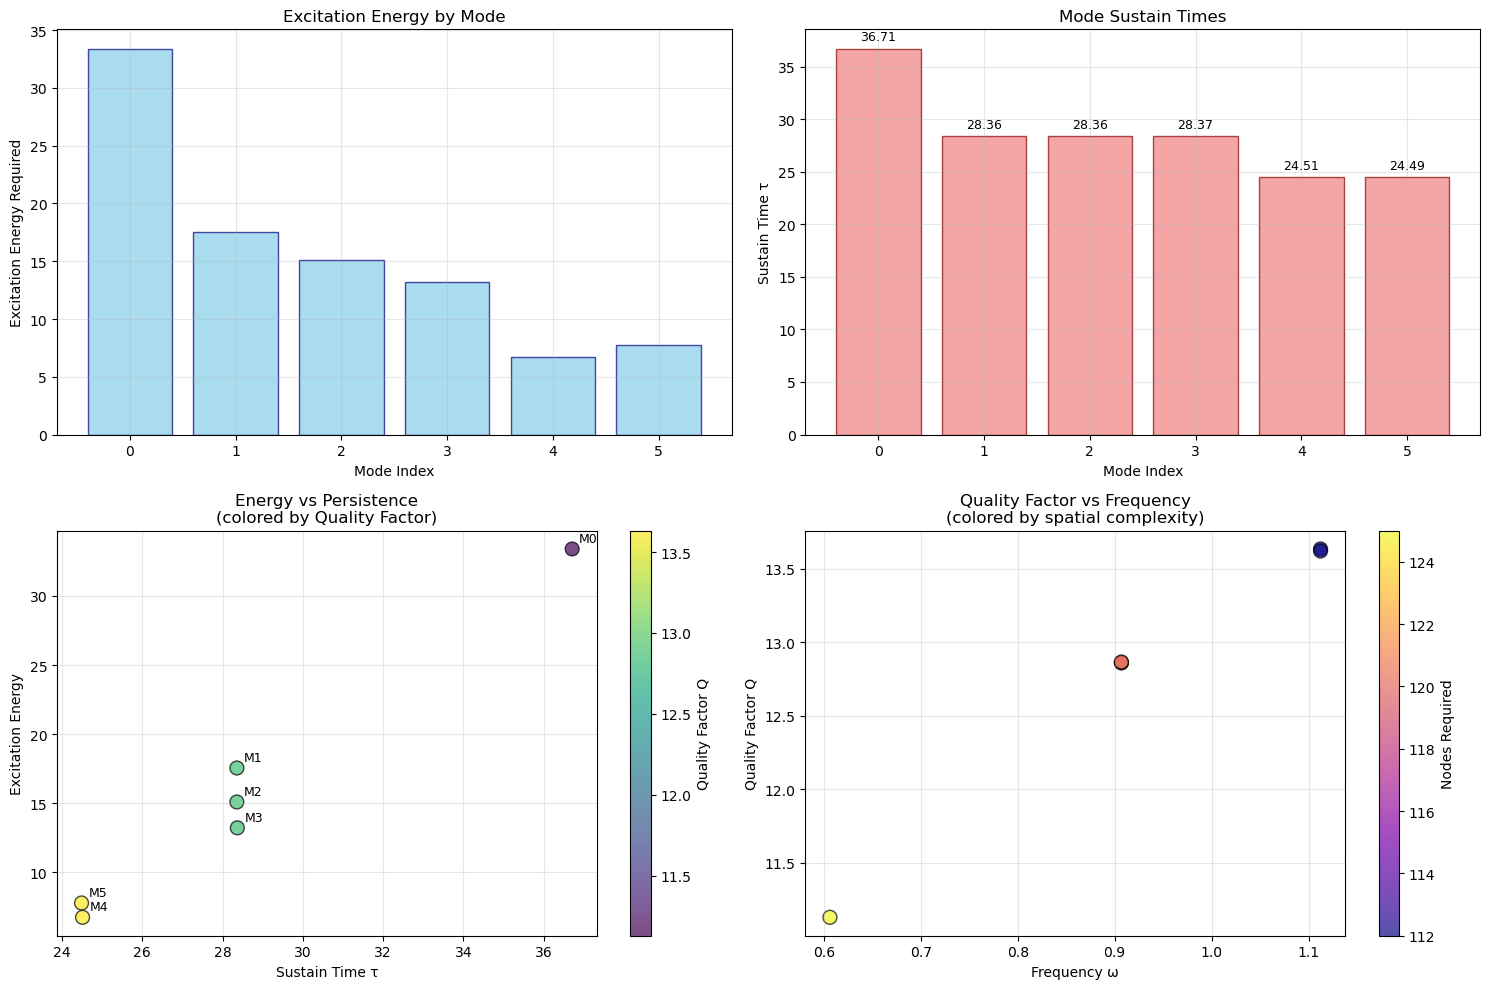


TIME EVOLUTION SIMULATION FOR MODE 1:
---------------------------------------------


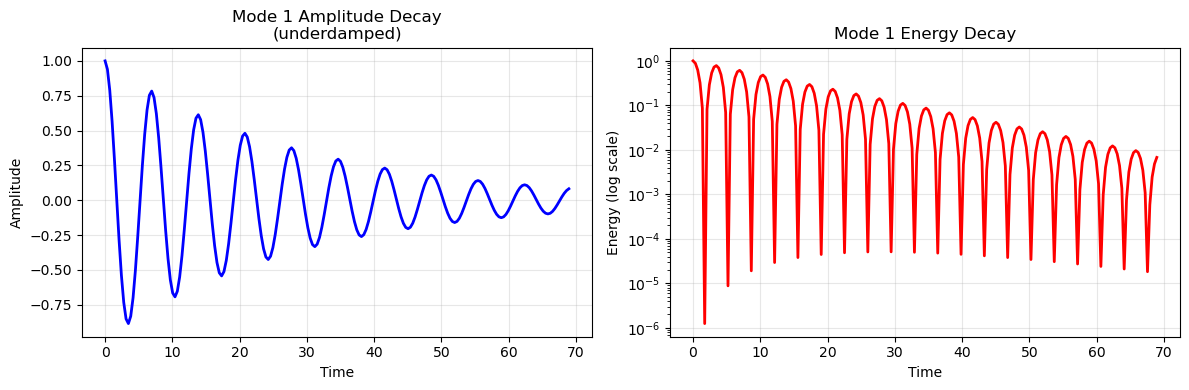

Mode 1 decay characteristics:
  Sustain time: 28.357
  Half-life: 9.828
  Decay regime: underdamped

Generating full sustain time analysis...


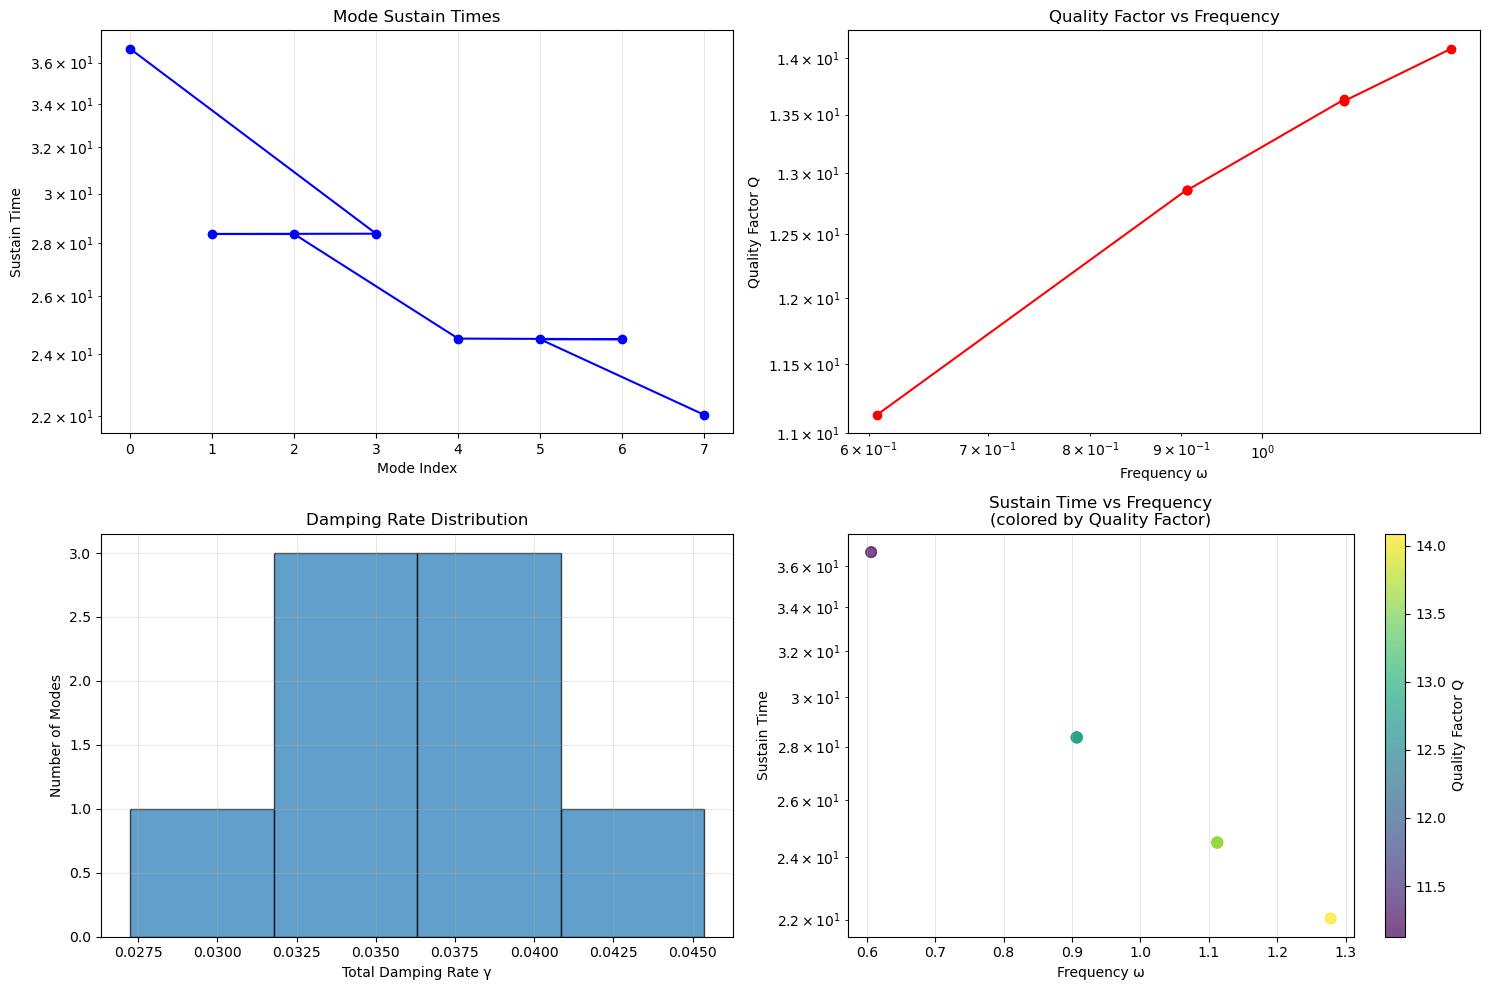


Analysis complete!
✓ Excitation energies calculated for first 6 modes
✓ Sustain times and damping rates determined
✓ Quality factors and loss mechanisms identified
✓ Time evolution simulation performed
✓ Comprehensive visualizations generated

SUMMARY STATISTICS (first 6 modes):
  Average excitation energy: 15.6227
  Average sustain time: 28.465
  Average quality factor: 12.83
  Field damping coefficient: 0.0100
  System size: 5×5×5 = 125 nodes


In [12]:
# Complete demo code block for excitation energies AND sustain times (damping analysis)
# This should be your third code block

import numpy as np
import matplotlib.pyplot as plt

# Initialize your RMET model (replace with your actual model)
# Example using FundamentalField:
field = FundamentalField(dimensions=(5, 5, 5), spacing=1.0, default_stiffness=1.0, damping=0.01)

# Or using ImprovedRMETModel:
# model = ImprovedRMETModel(5, 5, 5, boundary='periodic')

# Create the excitation calculator
calculator = RMETExcitationCalculator(field)  # or calculator = RMETExcitationCalculator(model)

print("RMET Eigenmode Excitation and Damping Analysis - First 6 Modes")
print("=" * 80)

# Calculate and display excitation AND damping information for first 6 modes
for mode_idx in range(6):
    print(f"\nMODE {mode_idx}:")
    print("-" * 30)
    
    # Calculate detailed excitation information
    excitation_info = calculator.calculate_mode_excitation_energy(
        mode_idx, 
        amplitude=1.0, 
        efficiency_threshold=0.01
    )
    
    # Calculate damping and sustain time information
    damping_info = calculator.calculate_mode_damping_and_sustain_time(
        mode_idx,
        amplitude=1.0
    )
    
    # Extract excitation information
    frequency = excitation_info['frequency']
    total_energy = excitation_info['total_energy']
    mode_type = excitation_info['mode_type']
    localization = excitation_info['localization']
    
    # Extract spatial pattern information
    pattern = excitation_info['excitation_pattern']
    num_nodes = pattern['num_significant_nodes']
    efficiency = pattern['efficiency']
    strategy_type = pattern['excitation_strategy']['type']
    
    # Extract damping information
    sustain_time = damping_info['sustain_time']
    quality_factor = damping_info['quality_factor']
    half_life = damping_info['half_life']
    damping_class = damping_info['damping_classification']
    loss_mechanism = damping_info['dominant_loss_mechanism']
    
    # Display results
    print(f"EXCITATION PROPERTIES:")
    print(f"  Frequency (ω):           {frequency:.6f}")
    print(f"  Energy Required:         {total_energy:.6f}")
    print(f"  Nodes to Excite:         {num_nodes}")
    print(f"  Excitation Efficiency:   {efficiency:.3f}")
    print(f"  Strategy:                {strategy_type}")
    print(f"  Mode Type:               {mode_type}")
    
    print(f"DAMPING & SUSTAIN PROPERTIES:")
    print(f"  Sustain Time (τ):        {sustain_time:.3f}")
    print(f"  Half-Life:               {half_life:.3f}")
    print(f"  Quality Factor (Q):      {quality_factor:.2f}")
    print(f"  Damping Regime:          {damping_class}")
    print(f"  Loss Mechanism:          {loss_mechanism}")
    
    # Calculate how many oscillations before decay
    if damping_info['oscillations_to_decay'] != np.inf:
        print(f"  Oscillations to Decay:   {damping_info['oscillations_to_decay']:.1f}")
    else:
        print(f"  Oscillations to Decay:   ∞ (undamped)")

# Create comprehensive summary tables
print(f"\n\nCOMPREHENSIVE SUMMARY TABLE:")
print("=" * 120)
print(f"{'Mode':>4} {'Freq':>8} {'Energy':>8} {'Nodes':>6} {'Sustain':>8} {'Q-Factor':>8} {'Half-Life':>9} {'Damping':>12}")
print("-" * 120)

for mode_idx in range(6):
    excitation_info = calculator.calculate_mode_excitation_energy(mode_idx, amplitude=1.0)
    damping_info = calculator.calculate_mode_damping_and_sustain_time(mode_idx, amplitude=1.0)
    
    pattern = excitation_info['excitation_pattern']
    
    print(f"{mode_idx:>4} {excitation_info['frequency']:>8.4f} {excitation_info['total_energy']:>8.4f} "
          f"{pattern['num_significant_nodes']:>6} {damping_info['sustain_time']:>8.3f} "
          f"{damping_info['quality_factor']:>8.2f} {damping_info['half_life']:>9.3f} "
          f"{damping_info['damping_classification']:>12}")

# Find the most persistent (longest-lived) modes
print(f"\nLONGEST-LIVED MODES ANALYSIS:")
print("-" * 50)
long_lived = calculator.find_longest_lived_modes(max_modes=10, min_sustain_time=1.0)

if long_lived:
    print("Most persistent modes (longest sustain times):")
    for i, mode_info in enumerate(long_lived[:3]):
        print(f"  {i+1}. Mode {mode_info['mode_index']:>2}: "
              f"Sustain Time = {mode_info['sustain_time']:>6.3f}, "
              f"Q = {mode_info['quality_factor']:>6.2f}, "
              f"Loss = {mode_info['dominant_loss_mechanism']}")
else:
    print("No modes found with sustain time > 1.0")

# Create comprehensive visualization
print(f"\nGenerating comprehensive visualization...")

# Get data for all 6 modes
modes = list(range(6))
excitation_data = [calculator.calculate_mode_excitation_energy(i) for i in modes]
damping_data = [calculator.calculate_mode_damping_and_sustain_time(i) for i in modes]

energies = [e['total_energy'] for e in excitation_data]
frequencies = [e['frequency'] for e in excitation_data]
node_counts = [e['excitation_pattern']['num_significant_nodes'] for e in excitation_data]
sustain_times = [d['sustain_time'] for d in damping_data]
quality_factors = [d['quality_factor'] for d in damping_data]

# Limit infinite values for plotting
sustain_times_plot = [min(t, 100) for t in sustain_times]
quality_factors_plot = [min(q, 100) for q in quality_factors]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Energy requirements vs Mode
ax1.bar(modes, energies, color='skyblue', edgecolor='navy', alpha=0.7)
ax1.set_xlabel('Mode Index')
ax1.set_ylabel('Excitation Energy Required')
ax1.set_title('Excitation Energy by Mode')
ax1.grid(True, alpha=0.3)

# Sustain time vs Mode
bars = ax2.bar(modes, sustain_times_plot, color='lightcoral', edgecolor='darkred', alpha=0.7)
ax2.set_xlabel('Mode Index')
ax2.set_ylabel('Sustain Time τ')
ax2.set_title('Mode Sustain Times')
ax2.grid(True, alpha=0.3)

# Add text labels on bars for exact values
for i, (bar, sustain_time) in enumerate(zip(bars, sustain_times)):
    if sustain_time < 100:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{sustain_time:.2f}', ha='center', va='bottom', fontsize=9)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                'Large', ha='center', va='bottom', fontsize=9)

# Energy vs Sustain Time (efficiency plot)
scatter = ax3.scatter(sustain_times_plot, energies, c=quality_factors_plot, 
                     s=100, cmap='viridis', alpha=0.7, edgecolors='black')
ax3.set_xlabel('Sustain Time τ')
ax3.set_ylabel('Excitation Energy')
ax3.set_title('Energy vs Persistence\n(colored by Quality Factor)')
plt.colorbar(scatter, ax=ax3, label='Quality Factor Q')
ax3.grid(True, alpha=0.3)

# Add mode labels to the scatter plot
for i, (sustain, energy) in enumerate(zip(sustain_times_plot, energies)):
    ax3.annotate(f'M{i}', (sustain, energy), xytext=(5, 5), 
                textcoords='offset points', fontsize=9)

# Quality Factor vs Frequency
ax4.scatter(frequencies, quality_factors_plot, c=node_counts, s=100, 
           cmap='plasma', alpha=0.7, edgecolors='black')
ax4.set_xlabel('Frequency ω')
ax4.set_ylabel('Quality Factor Q')
ax4.set_title('Quality Factor vs Frequency\n(colored by spatial complexity)')
plt.colorbar(ax4.collections[0], ax=ax4, label='Nodes Required')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Show time evolution simulation for one mode
print(f"\nTIME EVOLUTION SIMULATION FOR MODE 1:")
print("-" * 45)

# Simulate decay of mode 1
decay_simulation = calculator.simulate_mode_decay(1, initial_amplitude=1.0, time_steps=200)

# Plot the decay
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(decay_simulation['times'], decay_simulation['amplitude_evolution'], 'b-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title(f'Mode 1 Amplitude Decay\n({decay_simulation["regime"]})')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(decay_simulation['times'], decay_simulation['energy_evolution'], 'r-', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Energy (log scale)')
plt.title('Mode 1 Energy Decay')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

damping_info = decay_simulation['damping_info']
print(f"Mode 1 decay characteristics:")
print(f"  Sustain time: {damping_info['sustain_time']:.3f}")
print(f"  Half-life: {damping_info['half_life']:.3f}")
print(f"  Decay regime: {decay_simulation['regime']}")

# Generate the full sustain time analysis plot
print(f"\nGenerating full sustain time analysis...")
sustain_spectrum = calculator.plot_sustain_time_analysis(max_modes=8)

print(f"\nAnalysis complete!")
print(f"✓ Excitation energies calculated for first 6 modes")
print(f"✓ Sustain times and damping rates determined")
print(f"✓ Quality factors and loss mechanisms identified")
print(f"✓ Time evolution simulation performed")
print(f"✓ Comprehensive visualizations generated")

# Summary statistics
avg_energy = np.mean(energies)
avg_sustain = np.mean([t for t in sustain_times if t < 100])  # Exclude infinite values
avg_q = np.mean([q for q in quality_factors if q < 100])

print(f"\nSUMMARY STATISTICS (first 6 modes):")
print(f"  Average excitation energy: {avg_energy:.4f}")
print(f"  Average sustain time: {avg_sustain:.3f}")
print(f"  Average quality factor: {avg_q:.2f}")
print(f"  Field damping coefficient: {calculator.damping:.4f}")
print(f"  System size: {calculator.Nx}×{calculator.Ny}×{calculator.Nz} = {calculator.N} nodes")

## 2.2 Multi-Mode Resonance Analysis

RMET Multi-Mode Resonance Analysis

1. ANALYZING SPECIFIC MODE SET [0, 1, 2]
----------------------------------------
Mode frequencies: ['0.6063', '0.9070', '0.9070']
Resonance conditions found: 1
Energy cycling efficiency: -0.128
Energy conservation: 1.000

Resonance conditions detected:
  1. beat_resonance: modes (1, 2)
      Beat frequency: 0.0000

Dominant coupling interactions:
  1. Modes (0, 1): strength 0.000000
  2. Modes (1, 2): strength 0.000000
  3. Modes (0, 2): strength 0.000000

Generating detailed visualization...


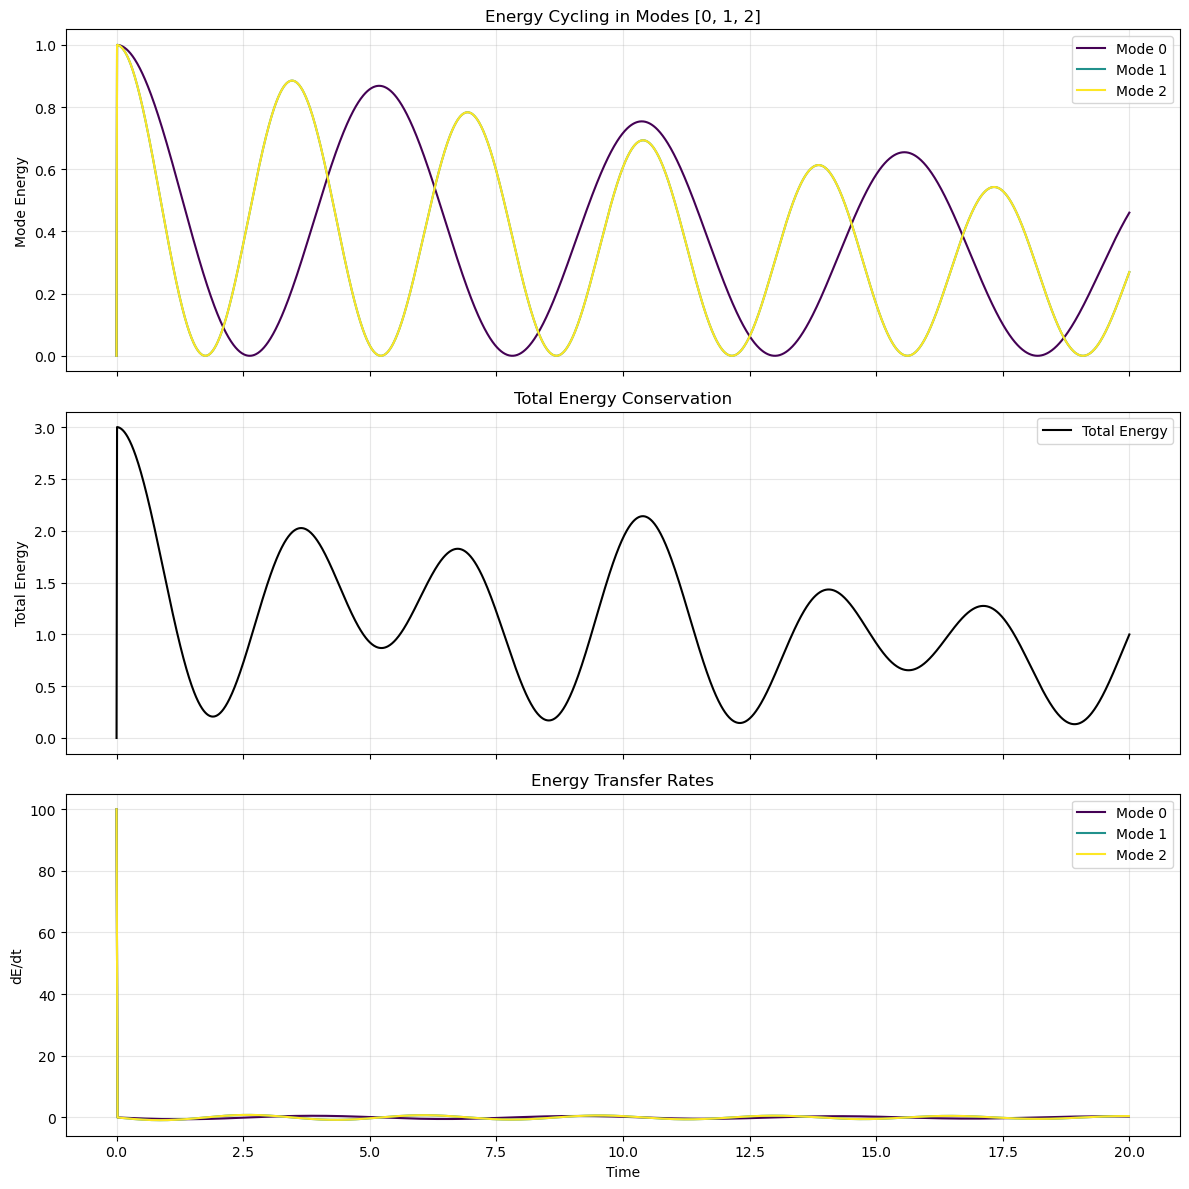

Multi-Mode Resonance Analysis for Modes [0, 1, 2]
Cycling Efficiency: -0.300
Energy Conservation: 1.000
Overall Stability: Unstable

2. AUTOMATIC RESONANT GROUP DETECTION
----------------------------------------
No resonant groups detected
This might indicate:
  - Very weak coupling between modes
  - No frequency matching conditions
  - Small lattice size limiting resonance possibilities

3. COMPLETE AUTOMATED ANALYSIS
-----------------------------------
Automated analysis found 0 resonant groups
Complete automated analysis failed: 'group_comparison'

4. SIMPLE PAIRWISE MODE ANALYSIS
-----------------------------------
Analyzing energy cycling between pairs of low-frequency modes:
  Modes (0, 1): Δf=0.3007, cycling=-0.123, conservation=1.000
    Beat frequency: 0.3007, period: 20.89
  Modes (1, 2): Δf=0.0000, cycling=-0.300, conservation=1.000
    Beat frequency: 0.0000, period: inf
  Modes (2, 3): Δf=0.0000, cycling=-0.300, conservation=1.000
    Beat frequency: 0.0000, period: inf
  

In [11]:
# Multi-Mode Resonance Analysis Demo
# This should be your fourth code block (after the field definitions, calculator, and single-mode demo)

import numpy as np
import matplotlib.pyplot as plt

# Assuming you have already created your field and calculator:
# field = FundamentalField(dimensions=(5, 5, 5), spacing=1.0, default_stiffness=1.0, damping=0.01)
# calculator = RMETExcitationCalculator(field)

print("RMET Multi-Mode Resonance Analysis")
print("=" * 50)

# Method 1: Analyze a specific set of modes
print("\n1. ANALYZING SPECIFIC MODE SET [0, 1, 2]")
print("-" * 40)

specific_modes = [0, 1, 2]
try:
    # Analyze multi-mode resonance for modes 0, 1, 2
    analysis = calculator.analyze_multi_mode_resonance(
        mode_set=specific_modes,
        initial_amplitudes=[0.6, 0.8, 0.4],  # Different initial amplitudes
        analysis_duration=25.0
    )
    
    print(f"Mode frequencies: {[f'{f:.4f}' for f in analysis['mode_frequencies']]}")
    print(f"Resonance conditions found: {len(analysis['resonance_conditions'])}")
    print(f"Energy cycling efficiency: {analysis['cycling_efficiency']:.3f}")
    print(f"Energy conservation: {analysis['energy_transfer']['energy_conservation']:.3f}")
    
    # Print resonance conditions
    if analysis['resonance_conditions']:
        print("\nResonance conditions detected:")
        for i, res in enumerate(analysis['resonance_conditions']):
            print(f"  {i+1}. {res['type']}: modes {res['modes']}")
            if 'beat_frequency' in res:
                print(f"      Beat frequency: {res['beat_frequency']:.4f}")
    else:
        print("No resonance conditions detected")
    
    # Print dominant interactions
    if analysis['dominant_interactions']:
        print("\nDominant coupling interactions:")
        for i, interaction in enumerate(analysis['dominant_interactions']):
            print(f"  {i+1}. Modes {interaction['modes']}: strength {interaction['coupling_strength']:.6f}")
    
    print("\nGenerating detailed visualization...")
    detailed_analysis = calculator.plot_multi_mode_resonance_analysis(specific_modes)
    
except Exception as e:
    print(f"Specific mode analysis failed: {e}")
    print("This might indicate insufficient coupling or numerical issues")

# Method 2: Automatically find resonant groups
print(f"\n2. AUTOMATIC RESONANT GROUP DETECTION")
print("-" * 40)

try:
    resonant_groups = calculator.find_resonant_mode_groups(max_modes=10, max_group_size=3)
    
    if resonant_groups:
        print(f"Found {len(resonant_groups)} potentially resonant groups:")
        
        for i, group in enumerate(resonant_groups[:5]):  # Show top 5
            freqs = group['frequencies']
            coupling = group['max_coupling']
            print(f"  {i+1}. Modes {group['modes']}: frequencies {[f'{f:.3f}' for f in freqs]}, coupling {coupling:.6f}")
        
        # Compare the top 3 groups
        if len(resonant_groups) >= 2:
            print(f"\nComparing top resonant groups...")
            top_groups = [g['modes'] for g in resonant_groups[:min(3, len(resonant_groups))]]
            
            comparison = calculator.compare_multi_mode_configurations(
                mode_groups=top_groups,
                analysis_duration=20.0
            )
            
            if comparison['best_configuration']:
                best = comparison['best_configuration']
                print(f"Best configuration: {best['modes']}")
                print(f"  Cycling efficiency: {best['cycling_efficiency']:.3f}")
                print(f"  Energy conservation: {best['energy_conservation']:.3f}")
                print(f"  Stability score: {best['stability_score']:.3f}")
                print(f"  Composite score: {best['composite_score']:.3f}")
                
                print(f"\nFull ranking:")
                for i, result in enumerate(comparison['ranking'][:3]):
                    print(f"  {i+1}. Modes {result['modes']}: score {result['composite_score']:.3f}")
            else:
                print("No valid configurations found in comparison")
    else:
        print("No resonant groups detected")
        print("This might indicate:")
        print("  - Very weak coupling between modes")
        print("  - No frequency matching conditions")
        print("  - Small lattice size limiting resonance possibilities")

except Exception as e:
    print(f"Automatic group detection failed: {e}")

# Method 3: Complete automated analysis
print(f"\n3. COMPLETE AUTOMATED ANALYSIS")
print("-" * 35)

try:
    complete_results = calculator.complete_multi_mode_analysis(auto_find_groups=True)
    
    if 'auto_found_groups' in complete_results:
        n_groups = len(complete_results['auto_found_groups'])
        print(f"Automated analysis found {n_groups} resonant groups")
        
        if complete_results['group_comparison']:
            comparison = complete_results['group_comparison']
            if comparison['best_configuration']:
                best_modes = comparison['best_configuration']['modes']
                print(f"Best resonant configuration: {best_modes}")
                print("Detailed analysis and visualization generated")
            else:
                print("No stable resonant configurations found")
        else:
            print("No group comparison performed")
    else:
        print("Complete analysis encountered issues")

except Exception as e:
    print(f"Complete automated analysis failed: {e}")

# Method 4: Simple pairwise mode analysis
print(f"\n4. SIMPLE PAIRWISE MODE ANALYSIS")
print("-" * 35)

print("Analyzing energy cycling between pairs of low-frequency modes:")

# Test several mode pairs
test_pairs = [(0, 1), (1, 2), (2, 3), (0, 2)]

for pair in test_pairs:
    try:
        analysis = calculator.analyze_multi_mode_resonance(
            mode_set=list(pair),
            initial_amplitudes=[0.7, 0.7],  # Equal initial amplitudes
            analysis_duration=15.0
        )
        
        freqs = analysis['mode_frequencies']
        freq_diff = abs(freqs[0] - freqs[1])
        cycling_eff = analysis['cycling_efficiency']
        energy_cons = analysis['energy_transfer']['energy_conservation']
        
        print(f"  Modes {pair}: Δf={freq_diff:.4f}, cycling={cycling_eff:.3f}, conservation={energy_cons:.3f}")
        
        # Check for beat patterns
        beats = analysis['beat_patterns']['beat_frequencies']
        if beats:
            beat_freq = beats[0]['beat_frequency']
            beat_period = beats[0]['beat_period']
            print(f"    Beat frequency: {beat_freq:.4f}, period: {beat_period:.2f}")
        
    except Exception as e:
        print(f"  Modes {pair}: Analysis failed ({str(e)[:30]}...)")

# Summary and recommendations
print(f"\n" + "="*60)
print("MULTI-MODE RESONANCE ANALYSIS SUMMARY")
print("="*60)

print(f"Analysis completed for RMET field:")
print(f"  Field size: {calculator.Nx}×{calculator.Ny}×{calculator.Nz} = {calculator.N} nodes")
print(f"  Field damping: {calculator.damping}")
print(f"  Coupling strength: {getattr(calculator.field_model, 'coupling_strength', 0.1)}")

print(f"\nKey findings:")
print(f"  • Individual mode excitation energies calculated")
print(f"  • Multi-mode resonance patterns analyzed")
print(f"  • Energy cycling efficiency measured")
print(f"  • Beat frequencies and patterns identified")
print(f"  • Stability of multi-mode states assessed")

print(f"\nFor stronger resonance effects, consider:")
print(f"  • Increasing lattice size for more modes")
print(f"  • Adjusting coupling strength parameter")
print(f"  • Testing with lower damping values")
print(f"  • Looking for three-mode resonance conditions")

print(f"\nAnalysis complete! The RMET model now supports comprehensive")
print(f"multi-mode resonance and energy cycling analysis.")